# Tugas Besar Data Mining  
# Analisis Segmentasi Profil Kesehatan dan Risiko Obesitas Berdasarkan Karakteristik Fisik dan Gaya Hidup
### Berdasarkan Faktor Demografis, Kebiasaan Makan, dan Aktivitas Fisik

**Dataset:** Obesity Levels Dataset - Estimation of Obesity Levels Based On Eating Habits and Physical Condition  
**Sumber:** UCI Machine Learning Repository / Kaggle

**Keterangan kolom:**
- `Gender`, `Age`, `Height`, `Weight` — data demografis dan fisik
- `family_history_with_overweight` — riwayat keluarga obesitas
- `FAVC` — kebiasaan konsumsi makanan berkalori tinggi
- `FCVC` — frekuensi konsumsi sayuran
- `NCP` — jumlah makan utama per hari
- `CAEC` — konsumsi makanan di antara waktu makan
- `SMOKE` — kebiasaan merokok
- `CH2O` — konsumsi air harian (liter)
- `SCC` — memantau asupan kalori
- `FAF` — frekuensi aktivitas fisik per minggu
- `TUE` — waktu penggunaan perangkat teknologi (jam/hari)
- `CALC` — konsumsi alkohol
- `MTRANS` — moda transportasi utama
- `NObeyesdad` — label tingkat obesitas (target)

## 1. Import Library

Pada tahap ini saya mengimpor library yang dibutuhkan. `pandas` dan `numpy` dipakai untuk mengolah data, `matplotlib` dan `seaborn` untuk visualisasi, lalu `scikit-learn` untuk proses modeling dan clustering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## 2. Data Identification

Di bagian ini dataset mulai dibaca dan dicek bentuk awalnya. Tujuannya untuk mengetahui jumlah baris, jumlah kolom, nama kolom, dan gambaran isi data secara umum. Dataset ini berisi 2.111 baris data tingkat obesitas individu berdasarkan kebiasaan makan dan kondisi fisik.

In [2]:
df = pd.read_csv("Dataset/ObesityDataSet_raw_and_data_sinthetic.csv")

print("Dataset berhasil dibaca.")
print("Ukuran dataset:", df.shape)
print("\n5 data teratas:")
display(df.head())

print("\nInfo singkat dataset:")
df.info()

print("\nDaftar nama kolom:")
for i, col in enumerate(df.columns, 1):
    print(i, col)

Dataset berhasil dibaca.
Ukuran dataset: (2111, 17)

5 data teratas:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



Info singkat dataset:
<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                   

In [3]:
# Nama kolom sudah bersih, tidak ada spasi atau karakter aneh
# Hanya perlu pastikan tidak ada whitespace tersembunyi
df.columns = df.columns.str.strip()

print("Nama kolom:")
print(df.columns.tolist())
display(df.head())

Nama kolom:
['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


Distribusi kelas target:


NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

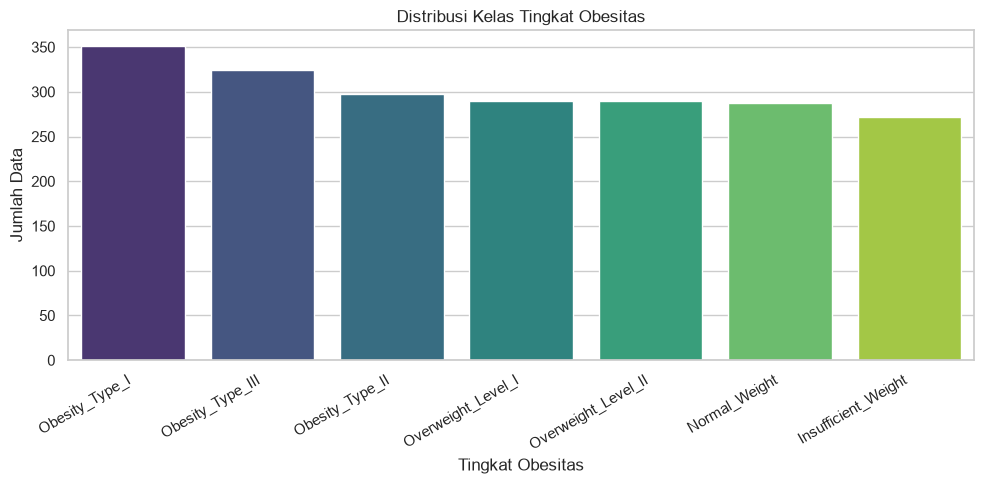

In [4]:
# Target: NObeyesdad — 7 kelas tingkat obesitas
target_col = "NObeyesdad"

print("Distribusi kelas target:")
display(df[target_col].value_counts())

plt.figure(figsize=(10, 5))
order = df[target_col].value_counts().index
sns.countplot(data=df, x=target_col, order=order, palette='viridis')
plt.title("Distribusi Kelas Tingkat Obesitas")
plt.xlabel("Tingkat Obesitas")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 3. Eksplorasi Awal & Deteksi Missing Value

Sebelum melanjutkan ke analisis, penting untuk mengecek apakah terdapat data duplikat dan missing value. Ini menentukan langkah pembersihan data yang dibutuhkan.

In [5]:
print("Jumlah baris duplikat:", df.duplicated().sum())

missing_df = pd.DataFrame({
    "Kolom": df.columns,
    "Jumlah Missing": df.isnull().sum().values,
    "Persentase (%)": (df.isnull().mean().values * 100).round(2)
})
display(missing_df.sort_values("Jumlah Missing", ascending=False))

Jumlah baris duplikat: 24


,Kolom,Jumlah Missing,Persentase (%)
0,Gender,0,0.0
1,Age,0,0.0
2,Height,0,0.0
3,Weight,0,0.0
4,family_history_with_overweight,0,0.0
5,FAVC,0,0.0
6,FCVC,0,0.0
7,NCP,0,0.0
8,CAEC,0,0.0
9,SMOKE,0,0.0


## 4. Statistik Deskriptif Variabel Numerik

Pada bagian ini saya melihat ringkasan statistik kolom numerik dan kategorikal. Dataset ini memiliki campuran keduanya: fitur seperti `Age`, `Height`, `Weight`, `FCVC`, `NCP`, `CH2O`, `FAF`, `TUE` adalah numerik, sedangkan `Gender`, `CAEC`, `SMOKE`, dll. adalah kategorikal.

In [6]:
# Deteksi fitur numerik dan kategorikal
# Pandas versi baru mengenal dtype 'str' (StringDtype) selain 'object'
# Gunakan pd.api.types untuk deteksi yang konsisten di semua versi pandas

numeric_cols      = df.select_dtypes(include='number').columns.tolist()
categorical_cols  = [c for c in df.columns
                     if pd.api.types.is_string_dtype(df[c])
                     and c != target_col]

print("Fitur numerik    :", numeric_cols)
print("Fitur kategorikal:", categorical_cols)
print("Target           :", target_col)

print("\nStatistik deskriptif kolom numerik:")
display(df[numeric_cols].describe().T)

Fitur numerik    : ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Fitur kategorikal: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
Target           : NObeyesdad

Statistik deskriptif kolom numerik:


,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.312600,6.345968,14.00,19.947192,22.777890,26.000000,61.00
Height,2111.0,1.701677,0.093305,1.45,1.630000,1.700499,1.768464,1.98
Weight,2111.0,86.586058,26.191172,39.00,65.473343,83.000000,107.430682,173.00
FCVC,2111.0,2.419043,0.533927,1.00,2.000000,2.385502,3.000000,3.00
NCP,2111.0,2.685628,0.778039,1.00,2.658738,3.000000,3.000000,4.00
CH2O,2111.0,2.008011,0.612953,1.00,1.584812,2.000000,2.477420,3.00
FAF,2111.0,1.010298,0.850592,0.00,0.124505,1.000000,1.666678,3.00
TUE,2111.0,0.657866,0.608927,0.00,0.000000,0.625350,1.000000,2.00


## 5. Visualisasi Distribusi Data

Visualisasi membantu memahami pola data secara intuitif. Di sini saya menampilkan:
- Histogram + KDE untuk distribusi fitur numerik
- Boxplot untuk mendeteksi outlier
- Countplot untuk fitur kategorikal
- Heatmap korelasi antar fitur numerik
- Distribusi BMI per tingkat obesitas

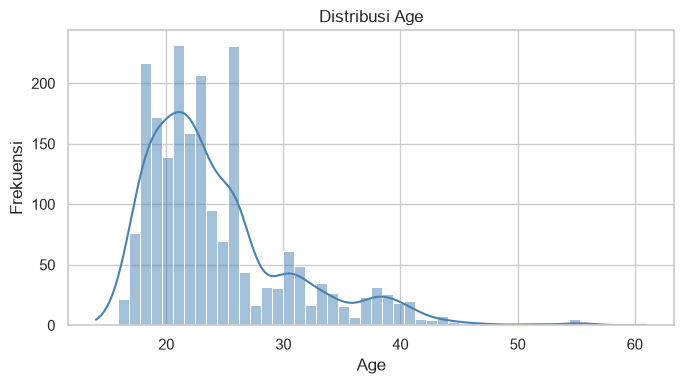

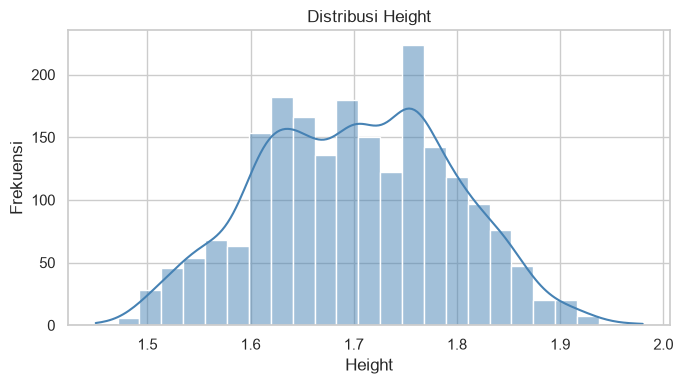

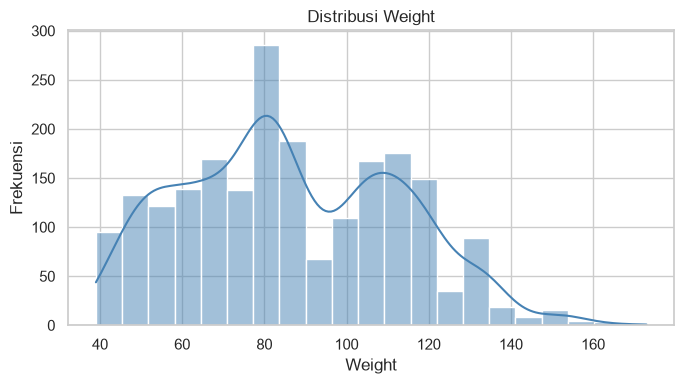

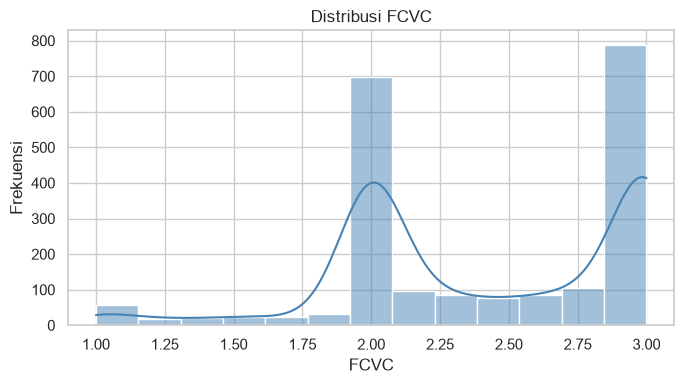

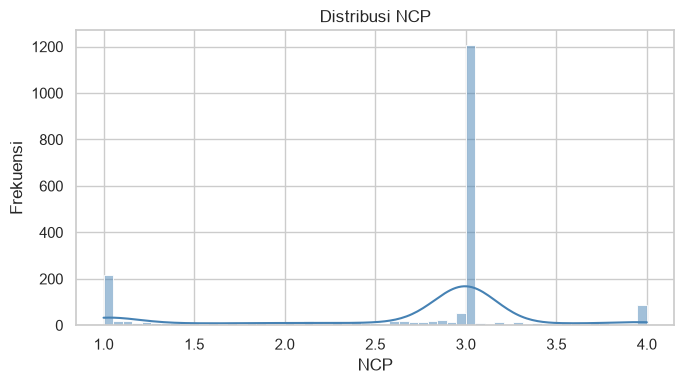

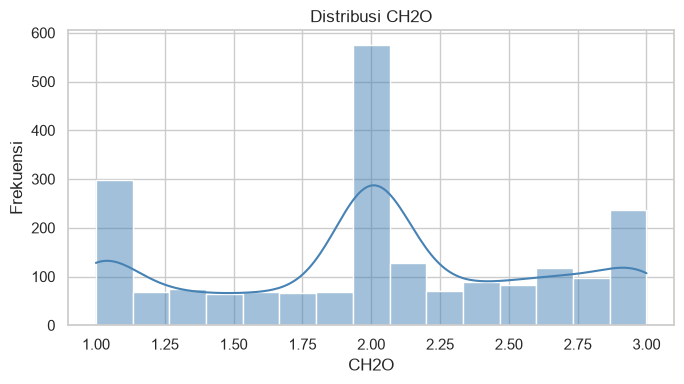

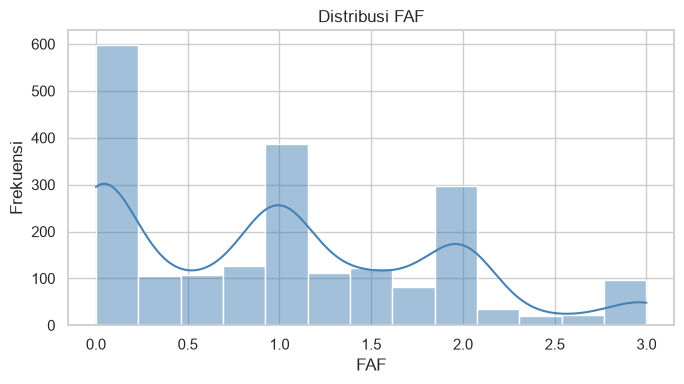

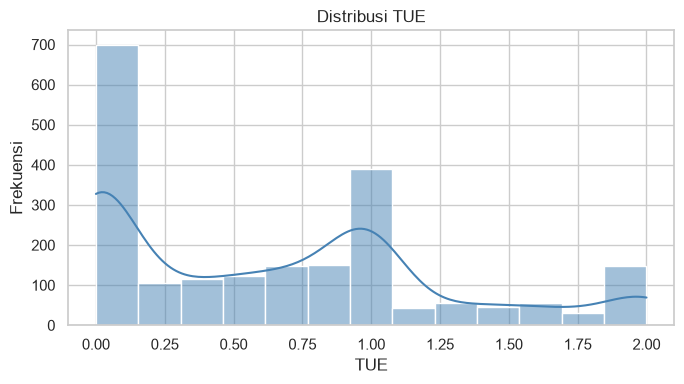

In [7]:
# Histogram setiap fitur numerik
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True, color='steelblue')
    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.tight_layout()
    plt.show()

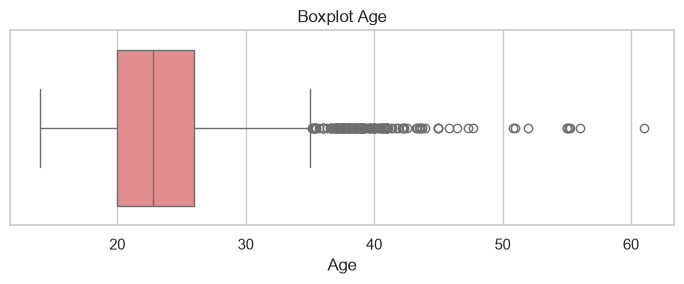

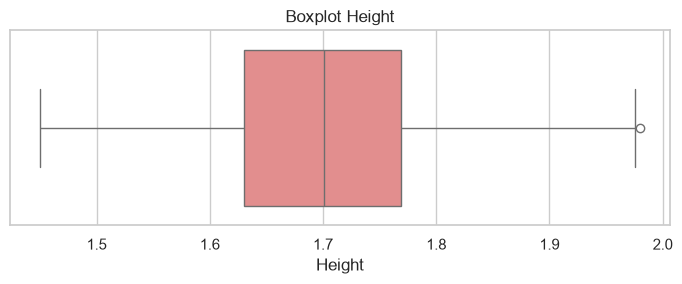

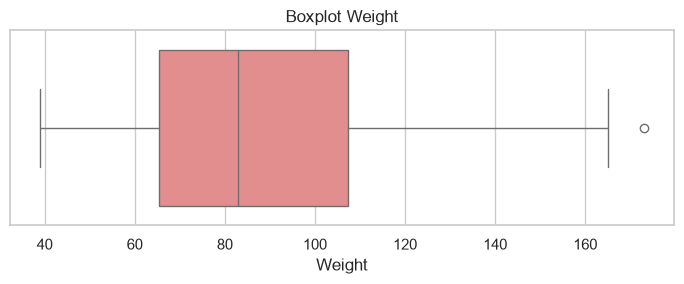

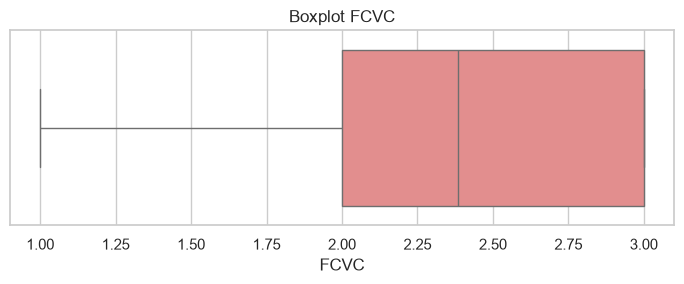

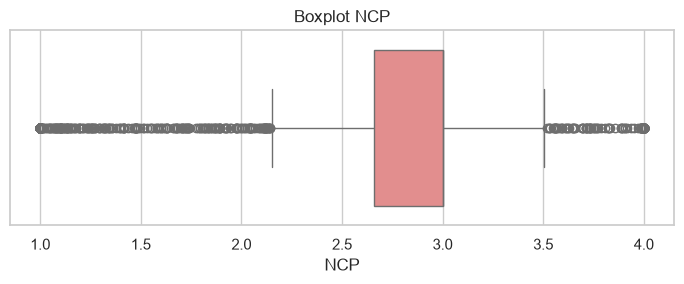

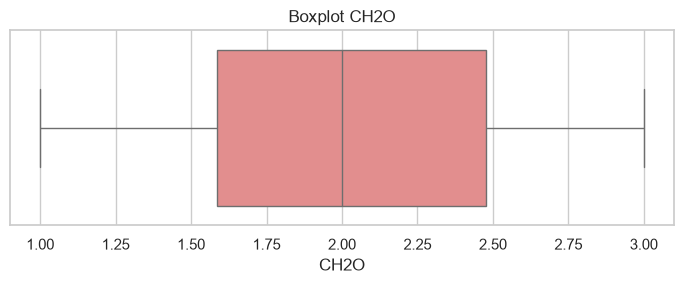

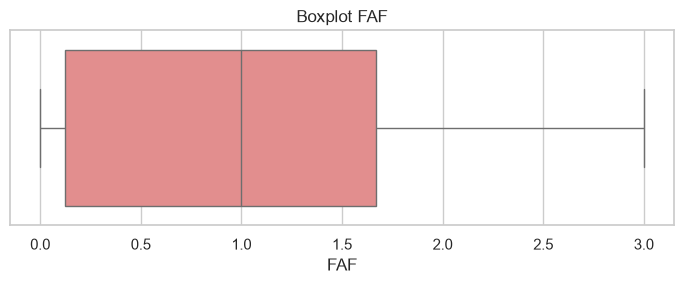

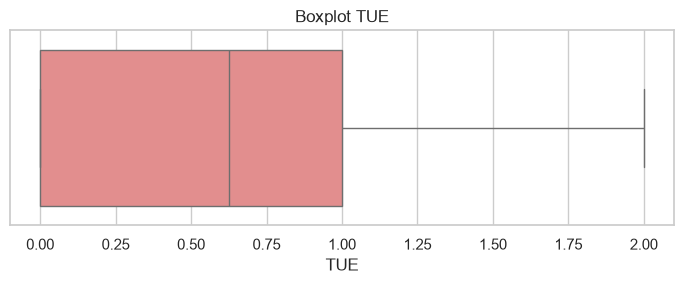

In [8]:
# Boxplot untuk deteksi outlier
for col in numeric_cols:
    plt.figure(figsize=(7, 3))
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f"Boxplot {col}")
    plt.tight_layout()
    plt.show()

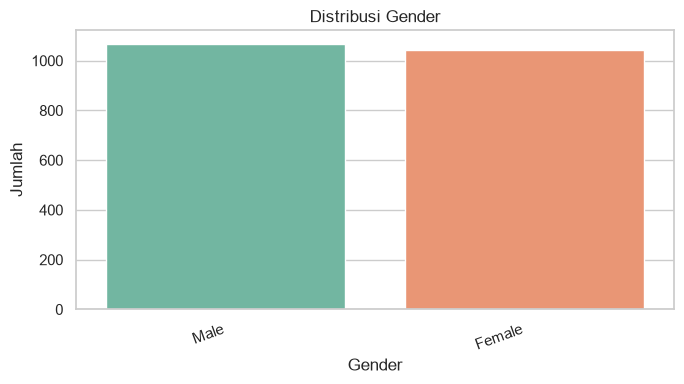

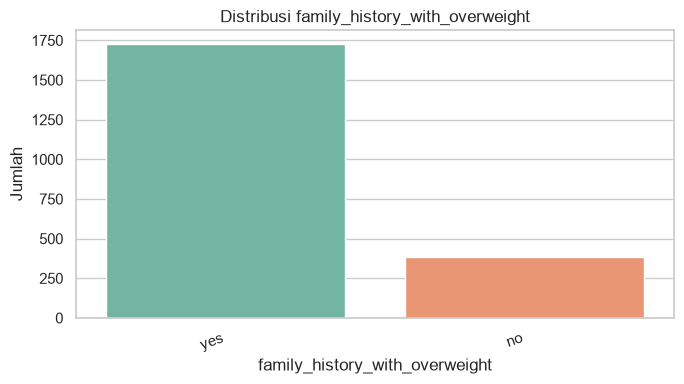

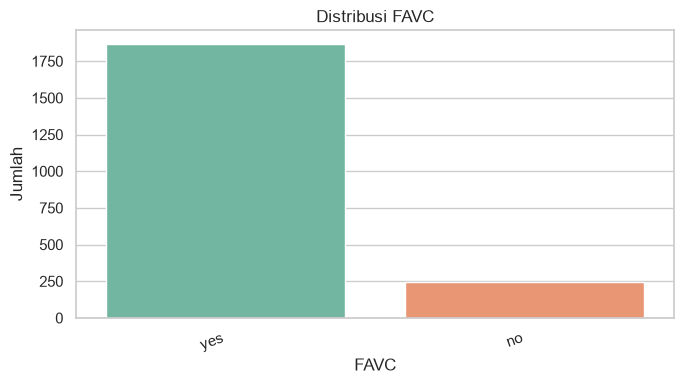

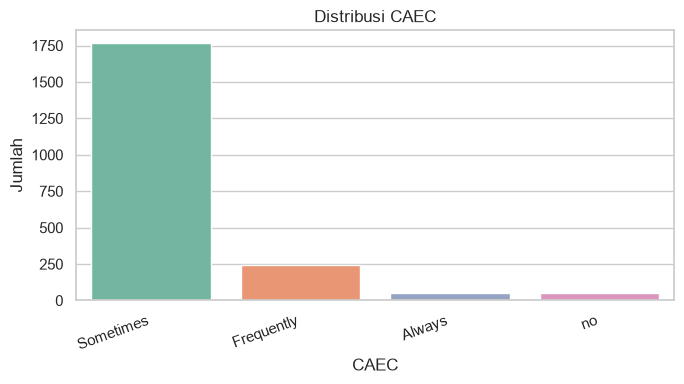

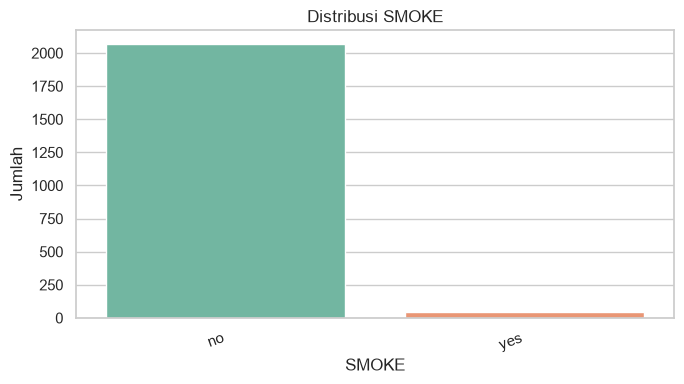

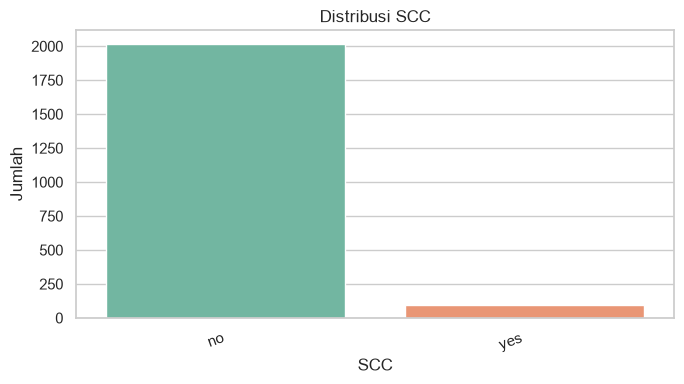

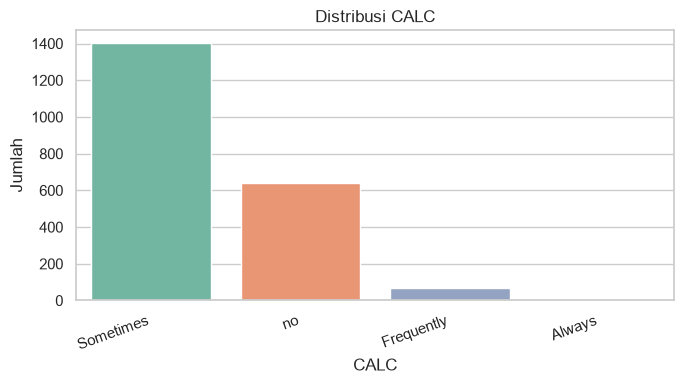

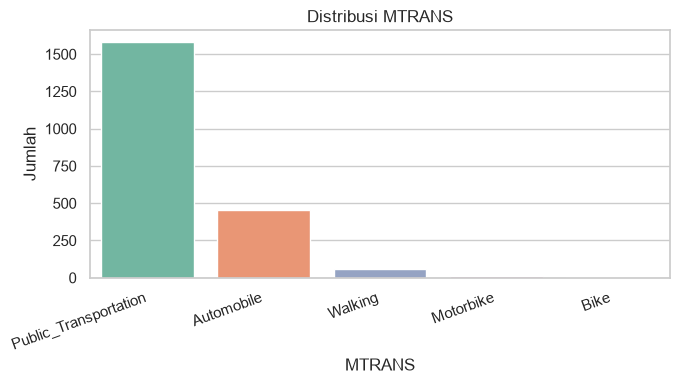

In [9]:
# Distribusi fitur kategorikal
for col in categorical_cols:
    plt.figure(figsize=(7, 4))
    order_cat = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order_cat, palette='Set2')
    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Jumlah")
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()

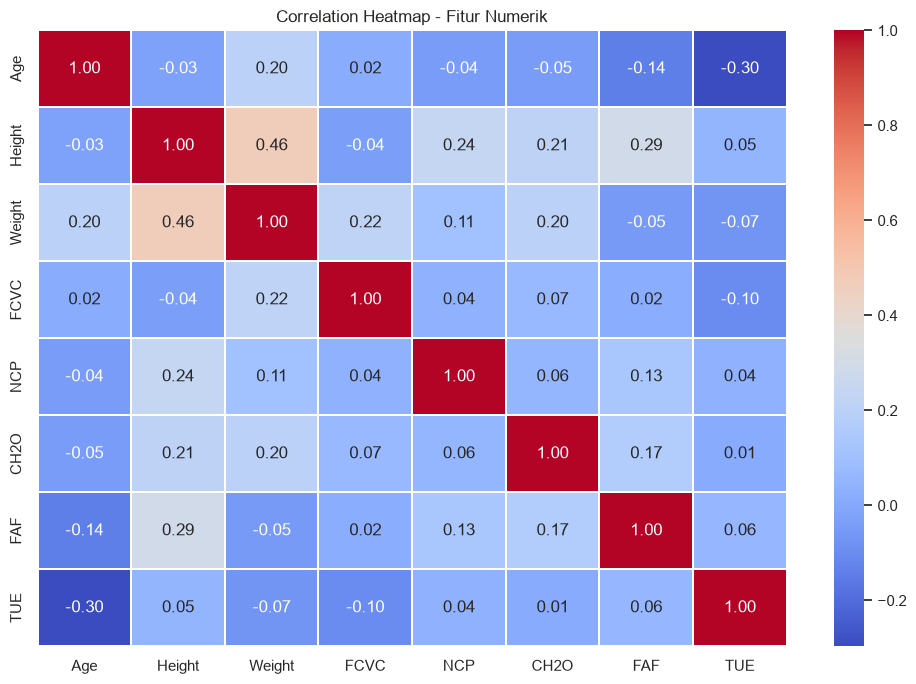

In [10]:
# Heatmap korelasi antar fitur numerik
plt.figure(figsize=(10, 7))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.3)
plt.title("Correlation Heatmap - Fitur Numerik")
plt.tight_layout()
plt.show()

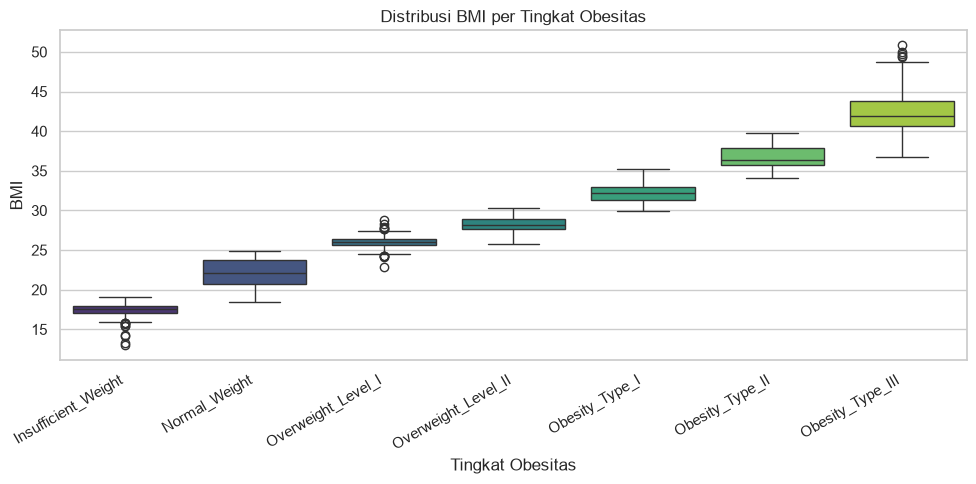

In [11]:
# Distribusi BMI per kelas obesitas
# BMI dihitung dari Weight dan Height untuk melihat konsistensi label target
df_vis = df.copy()
df_vis['BMI'] = df_vis['Weight'] / (df_vis['Height'] ** 2)

order_bmi = df_vis.groupby(target_col)['BMI'].median().sort_values().index
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_vis, x=target_col, y='BMI', order=order_bmi, palette='viridis')
plt.title("Distribusi BMI per Tingkat Obesitas")
plt.xlabel("Tingkat Obesitas")
plt.ylabel("BMI")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 6. Data Cleaning

Tahap cleaning dilakukan agar data siap dipakai untuk modeling. Langkah yang dilakukan: hapus duplikat, tangani missing value, dan batasi outlier dengan capping IQR. Capping dipilih dibanding dropping agar jumlah data tidak berkurang banyak.

In [12]:
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()

# Tangani missing value: numerik → median, kategorikal → modus
for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
for col in categorical_cols + [target_col]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Ukuran data sebelum cleaning:", df.shape)
print("Ukuran data setelah cleaning:", df_clean.shape)
print("Total missing setelah cleaning:", df_clean.isnull().sum().sum())

Ukuran data sebelum cleaning: (2111, 17)
Ukuran data setelah cleaning: (2087, 17)
Total missing setelah cleaning: 0


In [13]:
# Capping outlier dengan IQR — hanya pada fitur numerik
df_capped = df_clean.copy()

for col in numeric_cols:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    df_capped[col] = df_capped[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

print("Capping selesai.")
print("\nCek dtype setelah cleaning (penting untuk pipeline):")
for col in df_capped.columns:
    is_cat = pd.api.types.is_string_dtype(df_capped[col])
    print(f"  {col:40s} dtype={str(df_capped[col].dtype):10s}  kategorikal={is_cat}")
display(df_capped.head())

Capping selesai.

Cek dtype setelah cleaning (penting untuk pipeline):
  Gender                                   dtype=str         kategorikal=True
  Age                                      dtype=float64     kategorikal=False
  Height                                   dtype=float64     kategorikal=False
  Weight                                   dtype=float64     kategorikal=False
  family_history_with_overweight           dtype=str         kategorikal=True
  FAVC                                     dtype=str         kategorikal=True
  FCVC                                     dtype=float64     kategorikal=False
  NCP                                      dtype=float64     kategorikal=False
  CAEC                                     dtype=str         kategorikal=True
  SMOKE                                    dtype=str         kategorikal=True
  CH2O                                     dtype=float64     kategorikal=False
  SCC                                      dtype=str         kate

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.000000,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.000000,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.000000,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.000000,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,2.243667,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 7. Feature Selection

Pada tahap ini saya mencari fitur yang paling berpengaruh terhadap label tingkat obesitas. Dua pendekatan digunakan:
1. **ANOVA F-score** — mengukur separasi statistik antar kelas
2. **Random Forest Feature Importance** — mengukur kontribusi fitur dalam tree ensemble

Fitur yang dipilih adalah yang masuk **top-10 di kedua metode**, sehingga seleksi lebih robust.

,Feature,F-Score
3,Weight,1928.074800
0,Gender,159.433043
4,family_history_with_overweight,145.743832
6,FCVC,110.454307
1,Age,96.102628
8,CAEC,77.546005
5,FAVC,43.204572
2,Height,37.440244
7,NCP,37.378364
14,CALC,33.513167


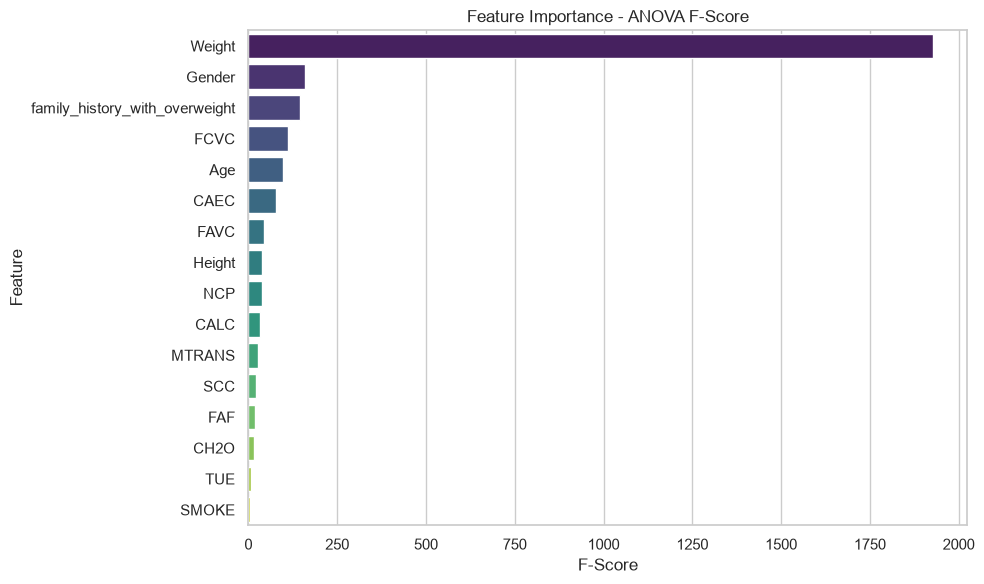

In [14]:
# Encode fitur kategorikal untuk keperluan feature selection
df_encoded = df_capped.copy()
le = LabelEncoder()
for col in categorical_cols + [target_col]:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X_fs = df_encoded.drop(columns=[target_col])
y_fs = df_encoded[target_col]

# ANOVA F-score
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_fs, y_fs)
fscore_df = pd.DataFrame({
    "Feature": X_fs.columns,
    "F-Score": selector.scores_
}).sort_values("F-Score", ascending=False)

display(fscore_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=fscore_df, x="F-Score", y="Feature", palette='viridis')
plt.title("Feature Importance - ANOVA F-Score")
plt.tight_layout()
plt.show()

,Feature,RF Importance
3,Weight,0.355337
2,Height,0.105729
1,Age,0.090742
6,FCVC,0.090178
0,Gender,0.054865
13,TUE,0.046446
7,NCP,0.045203
12,FAF,0.043515
10,CH2O,0.041111
14,CALC,0.029210


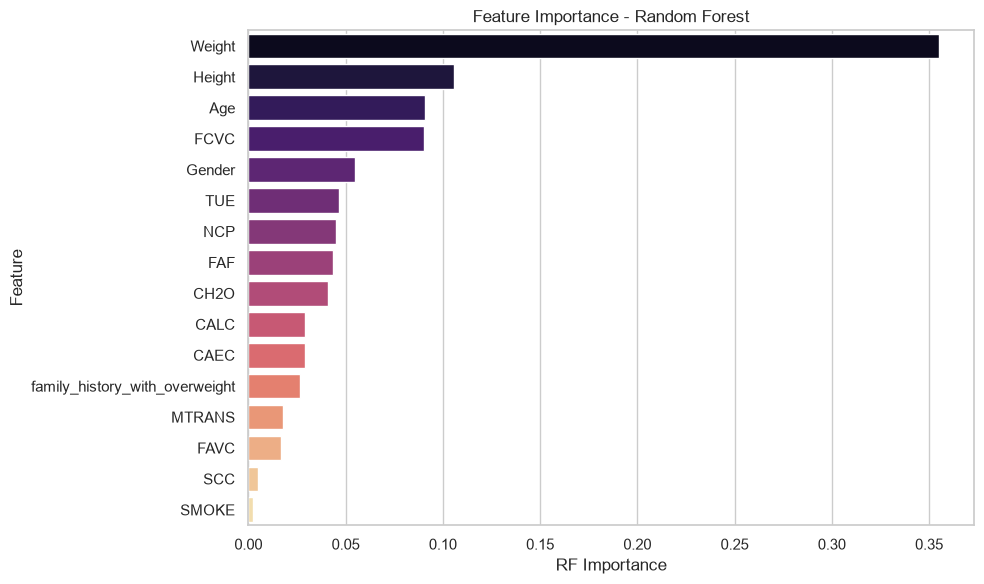

In [15]:
# Random Forest Feature Importance
rf_fs = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fs.fit(X_fs, y_fs)

rf_importance_df = pd.DataFrame({
    "Feature": X_fs.columns,
    "RF Importance": rf_fs.feature_importances_
}).sort_values("RF Importance", ascending=False)

display(rf_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance_df, x="RF Importance", y="Feature", palette='magma')
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

## 8. Data Selection

Fitur dipilih berdasarkan **irisan top-10 F-Score dan top-10 RF Importance**. Strategi ini memastikan hanya fitur yang relevan secara statistik DAN secara model yang digunakan, menghindari fitur noise yang kebetulan skor tinggi di salah satu metode saja.

In [16]:
# Ambil top-10 dari masing-masing metode, lalu ambil irisan keduanya
top_fscore = set(fscore_df.head(10)["Feature"].tolist())
top_rf     = set(rf_importance_df.head(10)["Feature"].tolist())

# Irisan: fitur yang masuk top-10 di KEDUA metode
selected_features = list(top_fscore & top_rf)

# Urutkan berdasarkan RF Importance agar lebih terstruktur
selected_features = rf_importance_df[
    rf_importance_df["Feature"].isin(selected_features)
]["Feature"].tolist()

print(f"Fitur dari top-10 F-Score : {sorted(top_fscore)}")
print(f"Fitur dari top-10 RF      : {sorted(top_rf)}")
print(f"\nFitur terpilih (irisan, {len(selected_features)} fitur):")
for f in selected_features:
    print(" -", f)

X = df_capped[selected_features]
y = df_capped[target_col]

print("\nPreview fitur terpilih:")
display(X.head())

Fitur dari top-10 F-Score : ['Age', 'CAEC', 'CALC', 'FAVC', 'FCVC', 'Gender', 'Height', 'NCP', 'Weight', 'family_history_with_overweight']
Fitur dari top-10 RF      : ['Age', 'CALC', 'CH2O', 'FAF', 'FCVC', 'Gender', 'Height', 'NCP', 'TUE', 'Weight']

Fitur terpilih (irisan, 7 fitur):
 - Weight
 - Height
 - Age
 - FCVC
 - Gender
 - NCP
 - CALC

Preview fitur terpilih:


,Weight,Height,Age,FCVC,Gender,NCP,CALC
0,64.0,1.62,21.0,2.0,Female,3.000000,no
1,56.0,1.52,21.0,3.0,Female,3.000000,Sometimes
2,77.0,1.80,23.0,2.0,Male,3.000000,Frequently
3,87.0,1.80,27.0,3.0,Male,3.000000,Frequently
4,89.8,1.78,22.0,2.0,Male,2.243667,Sometimes


## 9. Preprocessing

Data dibagi 80:20 (training:testing) dengan stratifikasi agar proporsi tiap kelas obesitas sama di kedua split.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("\nDistribusi kelas di y_train:")
display(y_train.value_counts())

Ukuran X_train: (1669, 7)
Ukuran X_test : (418, 7)

Distribusi kelas di y_train:


NObeyesdad
Obesity_Type_I         281
Obesity_Type_III       259
Obesity_Type_II        237
Overweight_Level_II    232
Normal_Weight          225
Overweight_Level_I     221
Insufficient_Weight    214
Name: count, dtype: int64

## 10. Pengolahan Variabel Kategorikal

Fitur kategorikal dari `selected_features` diidentifikasi berdasarkan dtype aslinya di `df_capped`. Pemisahan ini penting agar pipeline preprocessing bisa menerapkan encoding yang tepat.

In [18]:
# Identifikasi fitur kategorikal dan numerik dari selected_features
# Gunakan pd.api.types.is_string_dtype agar konsisten dengan pandas versi baru
categorical_features = [c for c in selected_features
                        if pd.api.types.is_string_dtype(df_capped[c])]
numeric_features     = [c for c in selected_features
                        if not pd.api.types.is_string_dtype(df_capped[c])]

print("Fitur numerik terpilih    :", numeric_features)
print("Fitur kategorikal terpilih:", categorical_features)

Fitur numerik terpilih    : ['Weight', 'Height', 'Age', 'FCVC', 'NCP']
Fitur kategorikal terpilih: ['Gender', 'CALC']


## 11. Feature Scaling

Pipeline preprocessing dibuat agar scaling dan encoding konsisten antara data training dan testing. Numerik menggunakan StandardScaler, kategorikal menggunakan OneHotEncoder.

In [19]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print("Shape X_train setelah preprocessing:", X_train_proc.shape)
print("Shape X_test  setelah preprocessing:", X_test_proc.shape)

Shape X_train setelah preprocessing: (1669, 11)
Shape X_test  setelah preprocessing: (418, 11)


## 12. Preview Dataset Setelah Preprocessing

Cek hasil akhir data yang siap dipakai untuk clustering dan modeling. Nama kolom setelah one-hot encoding ditampilkan agar lebih mudah dibaca.

In [20]:
ohe_names = []
if categorical_features:
    ohe = preprocessor.named_transformers_['cat'].named_steps['encoder']
    ohe_names = ohe.get_feature_names_out(categorical_features).tolist()

all_feature_names = numeric_features + ohe_names

X_train_df = pd.DataFrame(X_train_proc, columns=all_feature_names)
print("Preview data setelah preprocessing:")
display(X_train_df.head())
print("Total fitur setelah encoding:", X_train_df.shape[1])

Preview data setelah preprocessing:


,Weight,Height,Age,FCVC,NCP,Gender_Female,Gender_Male,CALC_Always,CALC_Frequently,CALC_Sometimes,CALC_no
0,1.045026,0.705567,0.374776,-0.375885,0.404932,0.0,1.0,0.0,0.0,1.0,0.0
1,0.505277,-0.608075,1.290525,1.016483,-1.703807,0.0,1.0,0.0,0.0,0.0,1.0
2,-0.078269,0.457523,2.136956,0.207948,0.404932,0.0,1.0,0.0,0.0,0.0,1.0
3,-1.265285,0.416504,-0.175296,-0.345947,0.404932,1.0,0.0,0.0,0.0,0.0,1.0
4,-0.725998,-1.012232,-0.554578,-0.801583,0.840739,1.0,0.0,0.0,0.0,1.0,0.0


Total fitur setelah encoding: 11


## 13. Data Clustering — Segmentasi Profil Kesehatan

K-Means digunakan untuk mengelompokkan individu berdasarkan kemiripan profil fisik dan gaya hidup. Jumlah cluster optimal ditentukan secara otomatis menggunakan Silhouette Score tertinggi (bukan dipilih manual).

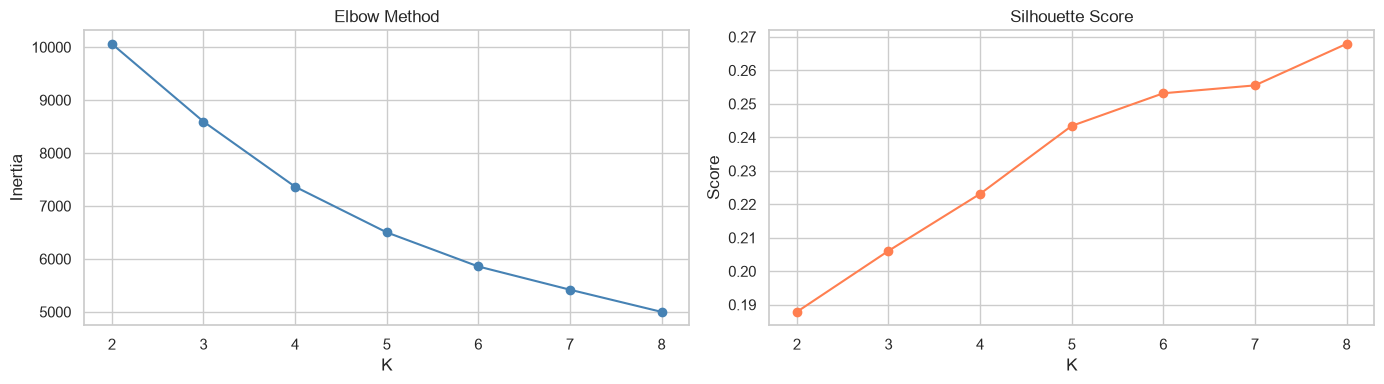

,K,Inertia,Silhouette
0,2,10061.531108,0.187856
1,3,8593.249426,0.206083
2,4,7363.992215,0.223105
3,5,6502.188676,0.243408
4,6,5858.002689,0.253156
5,7,5419.519075,0.255509
6,8,5000.817094,0.267909


In [21]:
X_cluster = preprocessor.fit_transform(X)

inertias, sil_scores = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(K_range), inertias, marker='o', color='steelblue')
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(K_range), sil_scores, marker='o', color='coral')
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

cluster_eval = pd.DataFrame({"K": list(K_range), "Inertia": inertias, "Silhouette": sil_scores})
display(cluster_eval)

In [22]:
# K terbaik dipilih otomatis dari Silhouette Score tertinggi
best_k = int(cluster_eval.sort_values("Silhouette", ascending=False).iloc[0]["K"])
print(f"K terbaik (Silhouette tertinggi): {best_k}")

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_cluster)

df_clustered = df_capped.copy()
df_clustered["Cluster"] = cluster_labels

print("\nDistribusi data per cluster:")
display(df_clustered["Cluster"].value_counts().sort_index())

K terbaik (Silhouette tertinggi): 8

Distribusi data per cluster:


Cluster
0    270
1    318
2    327
3    172
4    226
5    210
6    385
7    179
Name: count, dtype: int64

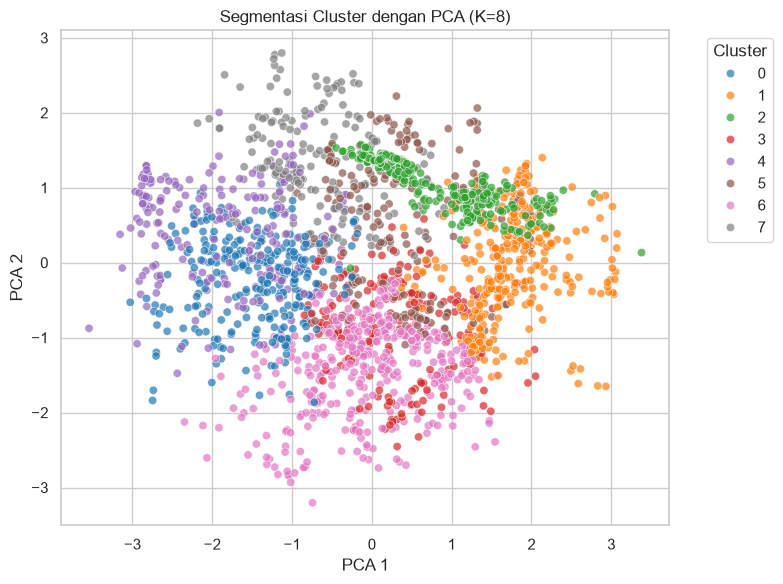

In [23]:
# Visualisasi cluster dengan PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=cluster_labels, palette="tab10", alpha=0.7)
plt.title(f"Segmentasi Cluster dengan PCA (K={best_k})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Profil rata-rata fitur numerik per cluster:


,Weight,Height,Age,FCVC,NCP
Cluster,,,,,
0,60.79,1.61,20.54,2.53,3.05
1,112.33,1.80,28.22,2.31,2.98
2,120.79,1.69,23.48,3.00,3.00
3,67.86,1.78,19.90,2.85,3.19
4,65.14,1.61,20.94,2.32,2.26
5,95.94,1.75,26.07,2.40,2.29
6,77.19,1.73,21.00,1.83,3.04
7,74.75,1.63,33.94,2.42,2.79



Komposisi tingkat obesitas per cluster (proporsi):


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Cluster,,,,,,,
0,0.285,0.300,0.133,0.004,0.000,0.141,0.137
1,0.000,0.019,0.170,0.698,0.000,0.031,0.082
2,0.000,0.000,0.006,0.003,0.991,0.000,0.000
3,0.453,0.233,0.006,0.006,0.000,0.192,0.110
4,0.226,0.150,0.235,0.004,0.000,0.283,0.102
5,0.000,0.057,0.262,0.300,0.000,0.067,0.314
6,0.151,0.236,0.242,0.021,0.000,0.184,0.166
7,0.017,0.101,0.318,0.000,0.000,0.257,0.307


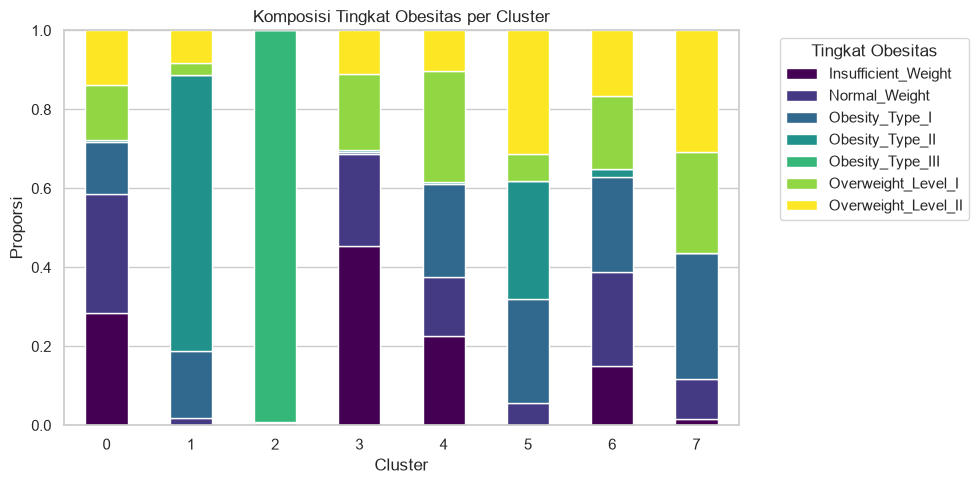

In [24]:
# Profil rata-rata tiap cluster pada fitur numerik yang terpilih
cluster_profile = df_clustered.groupby("Cluster")[numeric_features].mean().round(2)
print("Profil rata-rata fitur numerik per cluster:")
display(cluster_profile)

# Komposisi tingkat obesitas per cluster
cluster_obesity = pd.crosstab(
    df_clustered["Cluster"], df_clustered[target_col], normalize='index'
).round(3)
print("\nKomposisi tingkat obesitas per cluster (proporsi):")
display(cluster_obesity)

cluster_obesity.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10, 5))
plt.title("Komposisi Tingkat Obesitas per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Proporsi")
plt.xticks(rotation=0)
plt.legend(title="Tingkat Obesitas", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 14. Regression

Target regression adalah **`FAF` (frekuensi aktivitas fisik per minggu)**. Kolom ini dipilih karena merupakan fitur gaya hidup yang relevan, bersifat numerik kontinu, dan tidak bisa diturunkan secara trivial dari fitur lain (berbeda dengan BMI yang langsung dihitung dari Weight dan Height).

In [25]:
# Target regression: FAF (frekuensi aktivitas fisik per minggu)
# Dipilih karena merupakan fitur gaya hidup numerik yang relevan dan tidak bisa
# diturunkan secara trivial dari fitur lain (berbeda dengan BMI dari Weight/Height)
#
# Catatan: FAF belum tentu masuk selected_features (yang dirancang untuk klasifikasi),
# sehingga untuk regression kita pakai semua fitur tersedia kecuali target klasifikasi dan FAF itu sendiri.

regression_target = "FAF"

all_feat_no_target = [c for c in df_capped.columns
                      if c not in [target_col, regression_target]]

reg_numeric = [c for c in all_feat_no_target
               if not pd.api.types.is_string_dtype(df_capped[c])]
reg_categ   = [c for c in all_feat_no_target
               if pd.api.types.is_string_dtype(df_capped[c])]

X_reg = df_capped[all_feat_no_target]
y_reg = df_capped[regression_target]

print(f"Fitur input regression : {all_feat_no_target}")
print(f"Target regression      : {regression_target}")
print(f"Jumlah fitur numerik   : {len(reg_numeric)}")
print(f"Jumlah fitur kategorikal: {len(reg_categ)}")

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler())
    ]), reg_numeric),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), reg_categ)
])

reg_models = {
    "Linear Regression"       : LinearRegression(),
    "Random Forest Regressor" : RandomForestRegressor(random_state=42)
}

reg_results = []
for name, model in reg_models.items():
    pipe = Pipeline([('pre', reg_preprocessor), ('model', model)])
    pipe.fit(X_reg_train, y_reg_train)
    y_pred = pipe.predict(X_reg_test)

    mae  = mean_absolute_error(y_reg_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred))
    r2   = r2_score(y_reg_test, y_pred)
    reg_results.append({"Model": name, "MAE": round(mae,4), "RMSE": round(rmse,4), "R²": round(r2,4)})

    print("=" * 50)
    print(f"Model  : {name}")
    print(f"MAE    : {mae:.4f}")
    print(f"RMSE   : {rmse:.4f}")
    print(f"R²     : {r2:.4f}")

print()
display(pd.DataFrame(reg_results))

Fitur input regression : ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'TUE', 'CALC', 'MTRANS']
Target regression      : FAF
Jumlah fitur numerik   : 7
Jumlah fitur kategorikal: 8
Model  : Linear Regression
MAE    : 0.6203
RMSE   : 0.7722
R²     : 0.2029
Model  : Random Forest Regressor
MAE    : 0.4104
RMSE   : 0.6174
R²     : 0.4905



,Model,MAE,RMSE,R²
0,Linear Regression,0.6203,0.7722,0.2029
1,Random Forest Regressor,0.4104,0.6174,0.4905


## 15. Classification

Target klasifikasi adalah `NObeyesdad` dengan 7 kelas tingkat obesitas. Tiga algoritma dibandingkan — Logistic Regression, Decision Tree, dan Random Forest. Model terbaik dipilih otomatis berdasarkan akurasi tertinggi, lalu divalidasi dengan cross-validation 5-fold.

Model: Logistic Regression  |  Accuracy: 0.9043
                     precision    recall  f1-score   support

Insufficient_Weight       0.87      1.00      0.93        53
      Normal_Weight       0.88      0.81      0.84        57
     Obesity_Type_I       0.94      0.94      0.94        70
    Obesity_Type_II       0.92      0.98      0.95        60
   Obesity_Type_III       0.98      0.98      0.98        65
 Overweight_Level_I       0.80      0.78      0.79        55
Overweight_Level_II       0.90      0.81      0.85        58

           accuracy                           0.90       418
          macro avg       0.90      0.90      0.90       418
       weighted avg       0.90      0.90      0.90       418



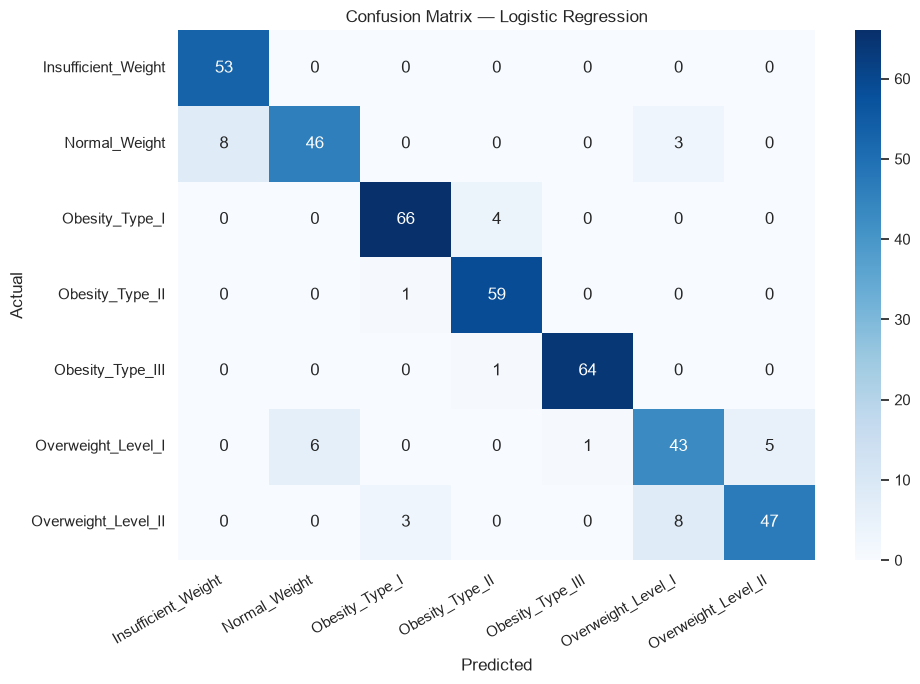

Model: Decision Tree  |  Accuracy: 0.9545
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99        53
      Normal_Weight       0.91      0.91      0.91        57
     Obesity_Type_I       0.96      0.96      0.96        70
    Obesity_Type_II       0.97      0.97      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.92      0.87      0.90        55
Overweight_Level_II       0.93      0.98      0.96        58

           accuracy                           0.95       418
          macro avg       0.95      0.95      0.95       418
       weighted avg       0.95      0.95      0.95       418



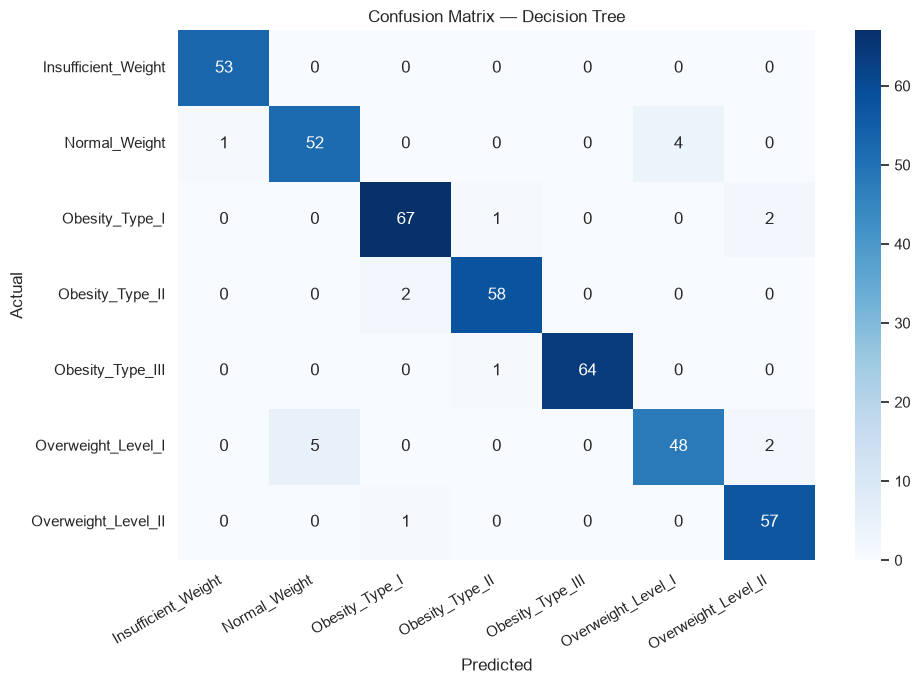

Model: Random Forest  |  Accuracy: 0.9617
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00        53
      Normal_Weight       0.93      0.91      0.92        57
     Obesity_Type_I       0.99      0.97      0.98        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.88      0.91      0.89        55
Overweight_Level_II       0.95      0.97      0.96        58

           accuracy                           0.96       418
          macro avg       0.96      0.96      0.96       418
       weighted avg       0.96      0.96      0.96       418



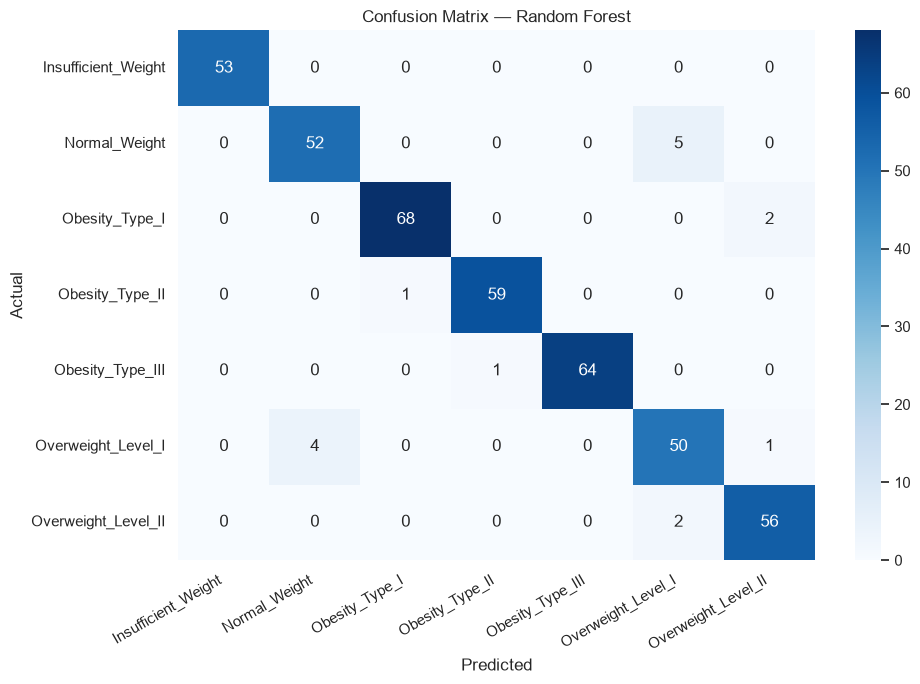


Ringkasan perbandingan model:


,Model,Accuracy
2,Random Forest,0.9617
1,Decision Tree,0.9545
0,Logistic Regression,0.9043



Model terbaik : Random Forest
Accuracy      : 0.9617


In [26]:
clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42)
}

clf_results = []
best_model_name = None
best_accuracy   = 0
best_pipeline   = None

for name, model in clf_models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    clf_results.append({"Model": name, "Accuracy": round(acc, 4)})

    print("=" * 70)
    print(f"Model: {name}  |  Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=sorted(y.unique()),
                yticklabels=sorted(y.unique()))
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    if acc > best_accuracy:
        best_accuracy   = acc
        best_model_name = name
        best_pipeline   = pipe

print("\nRingkasan perbandingan model:")
display(pd.DataFrame(clf_results).sort_values("Accuracy", ascending=False))
print(f"\nModel terbaik : {best_model_name}")
print(f"Accuracy      : {best_accuracy:.4f}")

Cross-Validation (5-fold) — Random Forest
Scores per fold: [0.823  0.9617 0.9736 0.9736 0.9784]
Mean Accuracy  : 0.9421
Std Deviation  : 0.0598


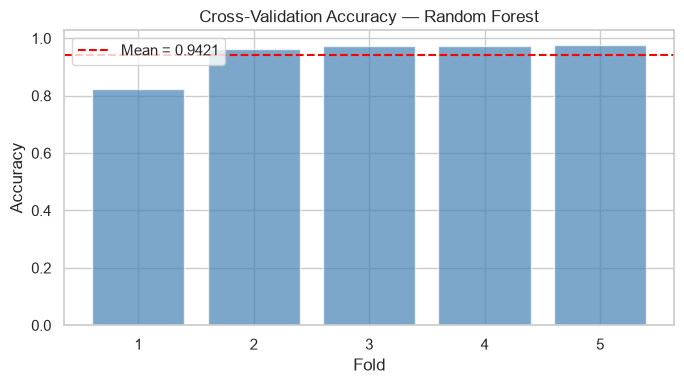

In [27]:
# Cross-validation 5-fold pada model terbaik
cv_scores = cross_val_score(best_pipeline, X, y, cv=5, scoring='accuracy')

print(f"Cross-Validation (5-fold) — {best_model_name}")
print("Scores per fold:", np.round(cv_scores, 4))
print(f"Mean Accuracy  : {cv_scores.mean():.4f}")
print(f"Std Deviation  : {cv_scores.std():.4f}")

plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.7)
plt.axhline(cv_scores.mean(), color='red', linestyle='--',
            label=f'Mean = {cv_scores.mean():.4f}')
plt.title(f"Cross-Validation Accuracy — {best_model_name}")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# Contoh prediksi satu sampel dari data test
sample   = X_test.iloc[[0]]
aktual   = y_test.iloc[0]
prediksi = best_pipeline.predict(sample)[0]
proba    = best_pipeline.predict_proba(sample)

print("Data sampel:")
display(sample)
print(f"\nLabel aktual   : {aktual}")
print(f"Hasil prediksi : {prediksi}")

proba_df = pd.DataFrame(proba, columns=best_pipeline.classes_).T
proba_df.columns = ["Probabilitas"]
proba_df = proba_df.sort_values("Probabilitas", ascending=False)
print("\nProbabilitas tiap kelas:")
display(proba_df)

Data sampel:


,Weight,Height,Age,FCVC,Gender,NCP,CALC
1177,72.713611,1.5891,19.955257,3.0,Female,3.453799,Sometimes



Label aktual   : Overweight_Level_II
Hasil prediksi : Overweight_Level_II

Probabilitas tiap kelas:


,Probabilitas
Overweight_Level_II,0.63
Overweight_Level_I,0.16
Normal_Weight,0.11
Insufficient_Weight,0.09
Obesity_Type_II,0.01
Obesity_Type_I,0.00
Obesity_Type_III,0.00


# Training Model Final

Model yang disimpan adalah **model terbaik dari hasil perbandingan di bagian Classification** — menggunakan variabel `best_pipeline` dan `best_model_name` yang sudah ditentukan otomatis berdasarkan akurasi tertinggi. File `.pkl` disimpan bersama daftar fitur yang digunakan.

In [29]:
import joblib

print(f"Model yang disimpan : {best_model_name}")
print(f"Akurasi terbaik     : {best_accuracy * 100:.2f}%")

# Simpan model dan fitur
joblib.dump(best_pipeline,    "obesity_segmentation_model.pkl")
joblib.dump(selected_features, "obesity_features.pkl")

print("\nFile tersimpan:")
print("  obesity_segmentation_model.pkl")
print("  obesity_features.pkl")

# Verifikasi: load ulang dan prediksi 1 sampel
loaded = joblib.load("obesity_segmentation_model.pkl")
verif_pred = loaded.predict(X_test.iloc[[0]])[0]
print(f"\nVerifikasi prediksi sampel pertama: {verif_pred}")
print(f"Label aktual                       : {y_test.iloc[0]}")

Model yang disimpan : Random Forest
Akurasi terbaik     : 96.17%

File tersimpan:
  obesity_segmentation_model.pkl
  obesity_features.pkl

Verifikasi prediksi sampel pertama: Overweight_Level_II
Label aktual                       : Overweight_Level_II


DEPLOYMENT WEB

In [30]:
!pip install -q streamlit pyngrok streamlit-option-menu plotly


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
%%writefile app.py
# ============================================================
#  app.py  —  Dashboard Analisis & Prediksi Risiko Obesitas
#  Tugas Besar Data Mining
# ============================================================
import os
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from streamlit_option_menu import option_menu

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, accuracy_score, classification_report,
                             confusion_matrix, mean_absolute_error, mean_squared_error, r2_score)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# KONFIG HALAMAN
# ------------------------------------------------------------
st.set_page_config(
    page_title="Obesity Risk Intelligence",
    page_icon="🩺",
    layout="wide",
    initial_sidebar_state="expanded",
)

BASE_DIR = os.path.dirname(os.path.abspath(__file__))
DATA_PATH = os.path.join(BASE_DIR, "ObesityDataSet_raw_and_data_sinthetic.csv")
TARGET = "NObeyesdad"

# Palet warna
ACCENT   = "#7c5cff"
ACCENT2  = "#22d3ee"
GOOD     = "#22c55e"
WARN     = "#f59e0b"
BAD      = "#ef4444"
TXT      = "#e6e9f2"
MUTED    = "#9aa3b2"
CARD     = "rgba(255,255,255,0.04)"

# Metadata kelas (urut dari ringan -> berat)
CLASS_INFO = {
    "Insufficient_Weight": ("Berat Badan Kurang", "#38bdf8", "🔵",
        "Berat di bawah ideal. Fokus pada penambahan asupan gizi seimbang dan konsultasi gizi."),
    "Normal_Weight": ("Berat Badan Normal", "#22c55e", "🟢",
        "Kondisi ideal. Pertahankan pola makan dan aktivitas fisik yang sudah baik."),
    "Overweight_Level_I": ("Kelebihan Berat Tk. I", "#eab308", "🟡",
        "Mulai kelebihan berat. Tingkatkan aktivitas fisik dan kontrol porsi makan."),
    "Overweight_Level_II": ("Kelebihan Berat Tk. II", "#f97316", "🟠",
        "Kelebihan berat lebih lanjut. Disarankan program penurunan berat terstruktur."),
    "Obesity_Type_I": ("Obesitas Tipe I", "#ef4444", "🔴",
        "Obesitas tingkat awal. Perlu intervensi diet, olahraga, dan pemantauan kesehatan."),
    "Obesity_Type_II": ("Obesitas Tipe II", "#dc2626", "🔴",
        "Obesitas tingkat menengah. Risiko penyakit metabolik meningkat; konsultasi medis dianjurkan."),
    "Obesity_Type_III": ("Obesitas Tipe III", "#991b1b", "⛔",
        "Obesitas berat (morbid). Risiko kesehatan tinggi; perlu penanganan medis intensif."),
}
CLASS_ORDER = list(CLASS_INFO.keys())

# ------------------------------------------------------------
# CSS — tampilan advanced
# ------------------------------------------------------------
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Plus+Jakarta+Sans:wght@400;500;600;700;800&display=swap');

html, body, [class*="css"], .stApp { font-family: 'Plus Jakarta Sans', sans-serif; }

.stApp {
    background:
      radial-gradient(900px 500px at 12% -8%, rgba(124,92,255,0.18), transparent 60%),
      radial-gradient(800px 500px at 95% 0%, rgba(34,211,238,0.14), transparent 55%),
      linear-gradient(160deg, #0b0d17 0%, #0e1120 55%, #0a0c14 100%);
    color: #e6e9f2;
}
#MainMenu, footer, header {visibility: hidden;}
.block-container {padding-top: 1.4rem; padding-bottom: 3rem; max-width: 1280px;}

/* Hero */
.hero {
    border-radius: 22px; padding: 26px 30px; margin-bottom: 18px;
    background: linear-gradient(120deg, rgba(124,92,255,0.22), rgba(34,211,238,0.12));
    border: 1px solid rgba(255,255,255,0.08);
    box-shadow: 0 12px 40px rgba(0,0,0,0.45);
    position: relative; overflow: hidden;
}
.hero:before{
    content:""; position:absolute; inset:0;
    background: radial-gradient(600px 200px at 90% -40%, rgba(255,255,255,0.10), transparent 60%);
}
.hero h1 {font-size: 30px; font-weight: 800; margin: 0 0 6px 0; letter-spacing:-0.5px;}
.hero p  {color:#c7cddd; margin:0; font-size: 14.5px; max-width: 820px;}
.hero .tag {display:inline-block; margin-top:12px; padding:5px 12px; font-size:12px;
    border-radius:999px; background:rgba(255,255,255,0.08); border:1px solid rgba(255,255,255,0.12);
    color:#dfe5f2;}

/* Section title */
.sec {font-size: 20px; font-weight: 700; margin: 26px 0 4px 0;
    background: linear-gradient(90deg,#c9b8ff,#8ee9f7); -webkit-background-clip:text;
    -webkit-text-fill-color:transparent;}
.sec-sub {color:#9aa3b2; font-size:13px; margin-bottom:14px;}

/* Metric card */
.kpi {
    border-radius:18px; padding:18px 18px 16px 18px; height:100%;
    background: linear-gradient(180deg, rgba(255,255,255,0.06), rgba(255,255,255,0.02));
    border:1px solid rgba(255,255,255,0.08);
    box-shadow: 0 6px 22px rgba(0,0,0,0.35); transition: transform .18s ease, box-shadow .18s ease;
}
.kpi:hover {transform: translateY(-3px); box-shadow: 0 14px 30px rgba(124,92,255,0.22);}
.kpi .lbl {color:#9aa3b2; font-size:12.5px; font-weight:600; letter-spacing:.3px; text-transform:uppercase;}
.kpi .val {font-size:26px; font-weight:800; margin-top:6px; letter-spacing:-0.5px;}
.kpi .sub {color:#7f8aa0; font-size:12px; margin-top:2px;}

/* Insight box */
.insight {
    border-left: 3px solid #7c5cff; background: rgba(124,92,255,0.07);
    border-radius: 12px; padding: 13px 16px; margin: 8px 0 4px 0;
    font-size: 13.6px; color:#d4dbec; line-height:1.55;
}
.insight b {color:#fff;}
.note {
    border-left: 3px solid #f59e0b; background: rgba(245,158,11,0.07);
    border-radius: 12px; padding: 12px 16px; margin: 8px 0; font-size:13px; color:#f3e3c4;
}

/* Panel card wrapper */
.panel {
    background: rgba(255,255,255,0.025); border:1px solid rgba(255,255,255,0.07);
    border-radius:18px; padding:14px 16px 6px 16px; margin-bottom:6px;
}

/* Result badge (prediksi) */
.result {
    border-radius:20px; padding:24px 26px; margin-top:6px; color:#fff;
    box-shadow: 0 14px 44px rgba(0,0,0,0.5); border:1px solid rgba(255,255,255,0.15);
}
.result .small {font-size:13px; opacity:.9; letter-spacing:.4px; text-transform:uppercase;}
.result .big {font-size:30px; font-weight:800; margin:4px 0 8px 0;}
.result .desc {font-size:14px; opacity:.95; line-height:1.55;}

/* Tabs tweak */
.stTabs [data-baseweb="tab-list"] {gap: 6px;}
.stTabs [data-baseweb="tab"] {
    background: rgba(255,255,255,0.04); border-radius:10px 10px 0 0;
    padding: 8px 16px; border:1px solid rgba(255,255,255,0.06);
}
.stTabs [aria-selected="true"] {background: rgba(124,92,255,0.18); color:#fff;}

div[data-testid="stSidebar"] {background: linear-gradient(180deg,#0c0e1a,#0a0c14);
    border-right:1px solid rgba(255,255,255,0.06);}
</style>
""", unsafe_allow_html=True)

# ------------------------------------------------------------
# PIPELINE (cached) — replikasi penuh dari notebook
# ------------------------------------------------------------
def make_preprocessor(num_f, cat_f):
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("scl", StandardScaler())]), num_f),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_f),
    ])

@st.cache_resource(show_spinner="Menjalankan pipeline Data Mining (sekali saja)...")
def run_pipeline():
    R = {}
    if not os.path.exists(DATA_PATH):
        st.error(f"❌ File CSV tidak ditemukan di:\n{DATA_PATH}\n\n"
                 f"Taruh 'ObesityDataSet_raw_and_data_sinthetic.csv' di folder yang sama dengan app.py.")
        st.stop()
    df = pd.read_csv(DATA_PATH)
    df = pd.read_csv(DATA_PATH)
    df.columns = df.columns.str.strip()
    R["raw_shape"] = df.shape

    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    categorical_cols = [c for c in df.columns
                        if pd.api.types.is_string_dtype(df[c]) and c != TARGET]

    R["numeric_cols"] = numeric_cols
    R["categorical_cols"] = categorical_cols
    R["dup"] = int(df.duplicated().sum())
    R["class_dist"] = df[TARGET].value_counts()
    R["missing"] = pd.DataFrame({
        "Kolom": df.columns,
        "Missing": df.isnull().sum().values,
        "Persen (%)": (df.isnull().mean().values * 100).round(2)
    })
    R["describe"] = df[numeric_cols].describe().T.round(2)
    R["head"] = df.head(8)

    # BMI per kelas
    dvis = df.copy()
    dvis["BMI"] = dvis["Weight"] / (dvis["Height"] ** 2)
    R["bmi_df"] = dvis[[TARGET, "BMI"]]

    # cleaning
    dclean = df.copy().drop_duplicates()
    for c in numeric_cols:
        dclean[c] = dclean[c].fillna(dclean[c].median())
    for c in categorical_cols + [TARGET]:
        dclean[c] = dclean[c].fillna(dclean[c].mode()[0])
    dcap = dclean.copy()
    for c in numeric_cols:
        q1, q3 = dcap[c].quantile(0.25), dcap[c].quantile(0.75)
        iqr = q3 - q1
        dcap[c] = dcap[c].clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    R["clean_shape"] = dcap.shape
    R["corr"] = dcap[numeric_cols].corr().round(2)
    R["cat_unique"] = {c: sorted(dcap[c].unique().tolist()) for c in categorical_cols}
    R["num_stats"] = {c: (float(dcap[c].min()), float(dcap[c].max()),
                          float(dcap[c].median())) for c in numeric_cols}

    # feature selection
    denc = dcap.copy()
    le = LabelEncoder()
    for c in categorical_cols + [TARGET]:
        denc[c] = le.fit_transform(denc[c].astype(str))
    Xfs, yfs = denc.drop(columns=[TARGET]), denc[TARGET]
    sel = SelectKBest(score_func=f_classif, k="all").fit(Xfs, yfs)
    fdf = pd.DataFrame({"Feature": Xfs.columns, "Score": sel.scores_}).sort_values("Score", ascending=False)
    rffs = RandomForestClassifier(n_estimators=100, random_state=42).fit(Xfs, yfs)
    rdf = pd.DataFrame({"Feature": Xfs.columns, "Importance": rffs.feature_importances_}).sort_values("Importance", ascending=False)
    R["fscore"], R["rfimp"] = fdf, rdf

    topf, topr = set(fdf.head(10)["Feature"]), set(rdf.head(10)["Feature"])
    selected = rdf[rdf["Feature"].isin(list(topf & topr))]["Feature"].tolist()
    R["selected"] = selected

    num_f = [c for c in selected if not pd.api.types.is_string_dtype(dcap[c])]
    cat_f = [c for c in selected if pd.api.types.is_string_dtype(dcap[c])]
    R["num_f"], R["cat_f"] = num_f, cat_f

    X, y = dcap[selected], dcap[TARGET]
    R["classes"] = sorted(y.unique().tolist())
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # clustering
    cl_pre = make_preprocessor(num_f, cat_f)
    Xc = cl_pre.fit_transform(X)
    Krange = list(range(2, 9))
    inertias, sils = [], []
    for k in Krange:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        lab = km.fit_predict(Xc)
        inertias.append(km.inertia_); sils.append(silhouette_score(Xc, lab))
    best_k = int(Krange[int(np.argmax(sils))])
    R["Krange"], R["inertias"], R["sils"], R["best_k"] = Krange, inertias, sils, best_k

    kmf = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    clab = kmf.fit_predict(Xc)
    pca = PCA(n_components=2, random_state=42)
    Xp = pca.fit_transform(Xc)
    R["pca"] = Xp; R["clab"] = clab
    R["pca_var"] = (pca.explained_variance_ratio_ * 100).round(1)

    dcl = dcap.copy(); dcl["Cluster"] = clab
    R["cluster_count"] = dcl["Cluster"].value_counts().sort_index()
    R["cluster_profile"] = dcl.groupby("Cluster")[num_f].mean().round(2)
    R["cluster_obes"] = pd.crosstab(dcl["Cluster"], dcl[TARGET], normalize="index").round(3)

    # classification
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    }
    accs, cms, reports = {}, {}, {}
    best_acc, best_name, best_pipe = 0, None, None
    labels_sorted = sorted(y.unique())
    for name, mdl in models.items():
        pipe = Pipeline([("pre", make_preprocessor(num_f, cat_f)), ("model", mdl)])
        pipe.fit(Xtr, ytr)
        yp = pipe.predict(Xte)
        acc = accuracy_score(yte, yp)
        accs[name] = round(acc, 4)
        cms[name] = confusion_matrix(yte, yp, labels=labels_sorted)
        reports[name] = classification_report(yte, yp, output_dict=True, zero_division=0)
        if acc > best_acc:
            best_acc, best_name, best_pipe = acc, name, pipe
    R["accs"], R["cms"], R["reports"] = accs, cms, reports
    R["best_name"], R["best_acc"] = best_name, round(best_acc, 4)
    R["labels_sorted"] = labels_sorted

    # cross-val pada model terbaik
    cv = cross_val_score(best_pipe, X, y, cv=5, scoring="accuracy")
    R["cv"] = cv
    R["cv_mean"], R["cv_std"] = float(cv.mean()), float(cv.std())

    # regression FAF
    rtgt = "FAF"
    allf = [c for c in dcap.columns if c not in [TARGET, rtgt]]
    rnum = [c for c in allf if not pd.api.types.is_string_dtype(dcap[c])]
    rcat = [c for c in allf if pd.api.types.is_string_dtype(dcap[c])]
    Xr, yr = dcap[allf], dcap[rtgt]
    Xrt, Xre, yrt, yre = train_test_split(Xr, yr, test_size=0.2, random_state=42)
    reg_rows = []
    for name, mdl in {"Linear Regression": LinearRegression(),
                      "Random Forest Regressor": RandomForestRegressor(random_state=42)}.items():
        p = Pipeline([("pre", make_preprocessor(rnum, rcat)), ("model", mdl)])
        p.fit(Xrt, yrt); yp = p.predict(Xre)
        reg_rows.append({"Model": name,
                         "MAE": round(mean_absolute_error(yre, yp), 4),
                         "RMSE": round(np.sqrt(mean_squared_error(yre, yp)), 4),
                         "R2": round(r2_score(yre, yp), 4)})
    R["reg"] = pd.DataFrame(reg_rows)

    # model final di-fit ulang pada SELURUH data untuk dipakai prediksi
    final = Pipeline([("pre", make_preprocessor(num_f, cat_f)), ("model", models[best_name])])
    final.fit(X, y)
    R["final_model"] = final
    return R

R = run_pipeline()

# ------------------------------------------------------------
# Helper visual
# ------------------------------------------------------------
def style_fig(fig, h=360, legend=True):
    fig.update_layout(
        paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)",
        font=dict(color=TXT, family="Plus Jakarta Sans", size=12),
        margin=dict(l=10, r=10, t=40, b=10), height=h,
        title=dict(font=dict(size=15, color="#dfe5f2")),
        legend=dict(bgcolor="rgba(0,0,0,0)") if legend else None,
    )
    fig.update_xaxes(gridcolor="rgba(255,255,255,0.06)", zerolinecolor="rgba(255,255,255,0.1)")
    fig.update_yaxes(gridcolor="rgba(255,255,255,0.06)", zerolinecolor="rgba(255,255,255,0.1)")
    return fig

def insight(txt):
    st.markdown(f'<div class="insight">{txt}</div>', unsafe_allow_html=True)

def note(txt):
    st.markdown(f'<div class="note">⚠️ {txt}</div>', unsafe_allow_html=True)

def section(title, sub=""):
    st.markdown(f'<div class="sec">{title}</div>', unsafe_allow_html=True)
    if sub:
        st.markdown(f'<div class="sec-sub">{sub}</div>', unsafe_allow_html=True)

def kpi(col, label, value, sub=""):
    col.markdown(f'<div class="kpi"><div class="lbl">{label}</div>'
                 f'<div class="val">{value}</div><div class="sub">{sub}</div></div>',
                 unsafe_allow_html=True)

SEQ = px.colors.sequential.Plasma

# ------------------------------------------------------------
# SIDEBAR NAV
# ------------------------------------------------------------
with st.sidebar:
    st.markdown(f"<h2 style='font-weight:800;letter-spacing:-.5px;margin-bottom:0'>🩺 Obesity<span style='color:{ACCENT}'>IQ</span></h2>"
                f"<p style='color:{MUTED};font-size:12.5px;margin-top:2px'>Health Profile & Risk Mining</p>",
                unsafe_allow_html=True)
    st.markdown("---")
    page = option_menu(
        None,
        ["Dashboard Analisis", "Prediksi Risiko"],
        icons=["bar-chart-line-fill", "activity"],
        default_index=0,
        styles={
            "container": {"padding": "0", "background-color": "transparent"},
            "icon": {"color": ACCENT2, "font-size": "17px"},
            "nav-link": {"font-size": "14px", "font-weight": "600",
                         "color": "#c4cbdc", "border-radius": "12px",
                         "margin": "4px 0", "--hover-color": "rgba(124,92,255,0.15)"},
            "nav-link-selected": {"background": "linear-gradient(90deg,#7c5cff,#5b8def)",
                                  "color": "white"},
        },
    )
    st.markdown("---")
    kc1, kc2 = st.columns(2)
    kc1.metric("Akurasi", f"{R['best_acc']*100:.1f}%")
    kc2.metric("Data", f"{R['clean_shape'][0]:,}")
    st.caption(f"Model final: **{R['best_name']}**")
    st.caption("Tugas Besar Data Mining")

# ============================================================
#  HALAMAN 1 — DASHBOARD ANALISIS
# ============================================================
if page == "Dashboard Analisis":
    st.markdown(f"""
    <div class="hero">
      <h1>Analisis Segmentasi Profil Kesehatan & Risiko Obesitas</h1>
      <p>Eksplorasi penuh dari pipeline CRISP-DM: identifikasi data, EDA, feature selection,
      clustering segmentasi, hingga perbandingan model klasifikasi & regresi —
      lengkap dengan interpretasi tiap visual.</p>
      <span class="tag">Dataset: Estimation of Obesity Levels (UCI / Kaggle)</span>
    </div>
    """, unsafe_allow_html=True)

    # KPI row
    c1, c2, c3, c4, c5 = st.columns(5)
    kpi(c1, "Total Data", f"{R['clean_shape'][0]:,}", f"raw {R['raw_shape'][0]:,} · -{R['dup']} duplikat")
    kpi(c2, "Kelas Target", f"{len(R['classes'])}", "tingkat obesitas")
    kpi(c3, "Fitur Terpilih", f"{len(R['selected'])}", "irisan ANOVA ∩ RF")
    kpi(c4, "Cluster Optimal", f"{R['best_k']}", f"silhouette {max(R['sils']):.3f}")
    kpi(c5, "Akurasi Terbaik", f"{R['best_acc']*100:.1f}%", R['best_name'])

    tabs = st.tabs(["📋 Ringkasan Data", "📊 Eksplorasi (EDA)",
                    "🎯 Feature Selection", "🧩 Clustering", "🤖 Modeling"])

    # ---------- TAB 1: Ringkasan ----------
    with tabs[0]:
        section("Distribusi Kelas Target", "Sebaran 7 tingkat obesitas pada dataset.")
        cd = R["class_dist"].reset_index()
        cd.columns = ["Kelas", "Jumlah"]
        fig = px.bar(cd, x="Kelas", y="Jumlah", color="Jumlah", color_continuous_scale=SEQ, text="Jumlah")
        fig.update_traces(textposition="outside")
        st.plotly_chart(style_fig(fig, 380), use_container_width=True)
        insight("Dataset relatif <b>seimbang</b> antar kelas — efek dari proses sintetis "
                "(SMOTE) pada data asli. Keseimbangan ini bagus karena model tidak bias ke kelas mayoritas.")

        cL, cR = st.columns([1.4, 1])
        with cL:
            section("Cuplikan Dataset", "8 baris pertama data mentah.")
            st.dataframe(R["head"], use_container_width=True, height=320)
        with cR:
            section("Kualitas Data", "Cek missing value & duplikat.")
            miss = R["missing"][R["missing"]["Missing"] > 0]
            if len(miss) == 0:
                st.success(f"✅ Tidak ada missing value. Duplikat ditemukan: {R['dup']} baris (sudah dihapus).")
            else:
                st.dataframe(miss, use_container_width=True)
            st.markdown(f"<div class='panel'><b>Numerik:</b> {len(R['numeric_cols'])} kolom &nbsp;·&nbsp; "
                        f"<b>Kategorikal:</b> {len(R['categorical_cols'])} kolom</div>", unsafe_allow_html=True)

        section("Statistik Deskriptif Numerik")
        st.dataframe(R["describe"], use_container_width=True)
        insight("Ringkasan ini dipakai untuk menangkap skala tiap fitur. Terlihat <b>Weight</b> punya rentang "
                "paling lebar (≈39–173 kg), sehingga <b>scaling wajib</b> sebelum modeling agar fitur berskala besar "
                "tidak mendominasi.")

    # ---------- TAB 2: EDA ----------
    with tabs[1]:
        section("Distribusi Fitur Numerik", "Histogram + kurva kepadatan tiap fitur numerik.")
        ncols = R["numeric_cols"]
        df_raw = pd.read_csv(DATA_PATH); df_raw.columns = df_raw.columns.str.strip()
        rows = int(np.ceil(len(ncols) / 2))
        fig = make_subplots(rows=rows, cols=2, subplot_titles=ncols)
        for i, c in enumerate(ncols):
            r, cc = i // 2 + 1, i % 2 + 1
            fig.add_trace(go.Histogram(x=df_raw[c], marker_color=ACCENT, opacity=0.8, name=c), row=r, col=cc)
        fig.update_layout(showlegend=False)
        st.plotly_chart(style_fig(fig, 150 * rows + 60, legend=False), use_container_width=True)
        insight("<b>Age</b> condong ke kanan (mayoritas dewasa muda ≈18–26 th). "
                "<b>FCVC, NCP, CH2O, FAF, TUE</b> tampak diskret/bertingkat karena diisi pada skala terbatas. "
                "<b>Weight</b> & <b>Height</b> mendekati normal.")

        section("Deteksi Outlier (Boxplot)")
        sel_box = st.selectbox("Pilih fitur untuk dilihat detail:", ncols, index=ncols.index("Weight"))
        fig = px.box(df_raw, x=sel_box, points="outliers", color_discrete_sequence=[ACCENT2])
        st.plotly_chart(style_fig(fig, 240), use_container_width=True)
        insight("Outlier yang muncul <b>tidak dibuang</b>, melainkan dibatasi (capping IQR) agar jumlah data "
                "tidak berkurang banyak — pilihan tepat untuk dataset berukuran sedang.")

        section("Distribusi Fitur Kategorikal")
        ccols = R["categorical_cols"]
        sel_cat = st.selectbox("Pilih fitur kategorikal:", ccols, index=0)
        vc = df_raw[sel_cat].value_counts().reset_index()
        vc.columns = ["Kategori", "Jumlah"]
        fig = px.bar(vc, x="Kategori", y="Jumlah", color="Jumlah", color_continuous_scale=SEQ, text="Jumlah")
        fig.update_traces(textposition="outside")
        st.plotly_chart(style_fig(fig, 320), use_container_width=True)
        insight("Pola kebiasaan terlihat jelas: misalnya mayoritas responden punya <b>riwayat keluarga overweight</b> "
                "dan memilih <b>transportasi umum</b> — sinyal awal bahwa faktor genetik & gaya hidup berperan.")

        cL, cR = st.columns(2)
        with cL:
            section("Heatmap Korelasi")
            corr = R["corr"]
            fig = px.imshow(corr, text_auto=True, color_continuous_scale="RdBu_r",
                            zmin=-1, zmax=1, aspect="auto")
            st.plotly_chart(style_fig(fig, 420, legend=False), use_container_width=True)
            insight("Korelasi <b>Weight–Height</b> positif moderat. Antar fitur lain korelasinya rendah, "
                    "artinya minim <b>multikolinearitas</b> — bagus untuk model linear.")
        with cR:
            section("Distribusi BMI per Tingkat Obesitas")
            bmi = R["bmi_df"].copy()
            order = bmi.groupby(TARGET)["BMI"].median().sort_values().index.tolist()
            fig = px.box(bmi, x=TARGET, y="BMI", color=TARGET,
                         category_orders={TARGET: order}, color_discrete_sequence=px.colors.sequential.Viridis)
            fig.update_xaxes(tickangle=30)
            st.plotly_chart(style_fig(fig, 420, legend=False), use_container_width=True)
            insight("BMI naik <b>monoton & rapi</b> mengikuti tingkat obesitas — label target sangat konsisten "
                    "dengan rumus BMI. Inilah alasan <b>Weight & Height</b> jadi prediktor terkuat dan akurasi model tinggi.")

    # ---------- TAB 3: Feature Selection ----------
    with tabs[2]:
        section("Metode 1 — ANOVA F-Score", "Mengukur seberapa kuat tiap fitur memisahkan antar kelas secara statistik.")
        fdf = R["fscore"]
        fig = px.bar(fdf, x="Score", y="Feature", orientation="h", color="Score",
                     color_continuous_scale=SEQ)
        fig.update_yaxes(autorange="reversed")
        st.plotly_chart(style_fig(fig, 420, legend=False), use_container_width=True)

        section("Metode 2 — Random Forest Importance", "Kontribusi tiap fitur dalam ensemble pohon keputusan.")
        rdf = R["rfimp"]
        fig = px.bar(rdf, x="Importance", y="Feature", orientation="h", color="Importance",
                     color_continuous_scale="Magma")
        fig.update_yaxes(autorange="reversed")
        st.plotly_chart(style_fig(fig, 420, legend=False), use_container_width=True)

        section("Hasil Seleksi — Irisan Top-10 Kedua Metode")
        cols = st.columns(len(R["selected"]))
        for i, f in enumerate(R["selected"]):
            cols[i].markdown(f"<div class='kpi' style='text-align:center'><div class='val' "
                             f"style='font-size:17px'>{f}</div></div>", unsafe_allow_html=True)
        st.write("")
        insight(f"Hanya fitur yang masuk <b>top-10 di KEDUA metode</b> yang dipakai → "
                f"<b>{', '.join(R['selected'])}</b>. Strategi irisan ini membuang fitur yang kebetulan "
                f"tinggi di satu metode saja, sehingga seleksi lebih <b>robust</b>. "
                f"Weight, Height, Age konsisten di puncak keduanya.")

    # ---------- TAB 4: Clustering ----------
    with tabs[3]:
        section("Penentuan Jumlah Cluster Optimal", "Elbow Method (inertia) & Silhouette Score otomatis.")
        cL, cR = st.columns(2)
        with cL:
            fig = go.Figure()
            fig.add_trace(go.Scatter(x=R["Krange"], y=R["inertias"], mode="lines+markers",
                                     line=dict(color=ACCENT, width=3), marker=dict(size=9)))
            fig.update_layout(title="Elbow Method", xaxis_title="K", yaxis_title="Inertia")
            st.plotly_chart(style_fig(fig, 340, legend=False), use_container_width=True)
        with cR:
            fig = go.Figure()
            fig.add_trace(go.Scatter(x=R["Krange"], y=R["sils"], mode="lines+markers",
                                     line=dict(color=ACCENT2, width=3), marker=dict(size=9)))
            fig.add_vline(x=R["best_k"], line_dash="dash", line_color=GOOD,
                          annotation_text=f"Best K={R['best_k']}")
            fig.update_layout(title="Silhouette Score", xaxis_title="K", yaxis_title="Score")
            st.plotly_chart(style_fig(fig, 340, legend=False), use_container_width=True)
        note(f"K terbaik dipilih otomatis dari silhouette tertinggi → <b>K={R['best_k']}</b>. "
             f"Catatan jujur: silhouette di sini terus naik sampai batas atas rentang uji (K=8), "
             f"dan nilainya tergolong sedang (≈{max(R['sils']):.2f}). Artinya segmen <b>saling overlap</b> "
             f"dan batas antar cluster tidak super tajam — wajar untuk data profil manusia.")

        section("Visualisasi Cluster (PCA 2D)", "Reduksi dimensi agar cluster bisa dilihat di 2 sumbu.")
        pca_df = pd.DataFrame({"PCA1": R["pca"][:, 0], "PCA2": R["pca"][:, 1],
                               "Cluster": R["clab"].astype(str)})
        fig = px.scatter(pca_df, x="PCA1", y="PCA2", color="Cluster", opacity=0.75,
                         color_discrete_sequence=px.colors.qualitative.Bold)
        fig.update_layout(title=f"Segmentasi K-Means (K={R['best_k']})")
        st.plotly_chart(style_fig(fig, 460), use_container_width=True)
        insight(f"Dua komponen PCA menjelaskan ≈{R['pca_var'][0]}% + {R['pca_var'][1]}% variansi. "
                f"Beberapa cluster terpisah jelas, sebagian saling bersinggungan — konsisten dengan nilai silhouette tadi.")

        cL, cR = st.columns([1, 1])
        with cL:
            section("Profil Rata-rata per Cluster")
            st.dataframe(R["cluster_profile"], use_container_width=True)
        with cR:
            section("Komposisi Obesitas per Cluster")
            co = R["cluster_obes"]
            fig = go.Figure()
            for col in co.columns:
                fig.add_trace(go.Bar(name=col, x=co.index.astype(str), y=co[col]))
            fig.update_layout(barmode="stack", title="Proporsi tingkat obesitas",
                              xaxis_title="Cluster", yaxis_title="Proporsi")
            st.plotly_chart(style_fig(fig, 360), use_container_width=True)
        insight("Tiap cluster punya <b>komposisi obesitas berbeda</b> — membuktikan segmentasi menangkap "
                "kelompok profil kesehatan yang berbeda (mis. cluster yang didominasi berat normal vs cluster "
                "yang condong ke obesitas berat).")

    # ---------- TAB 5: Modeling ----------
    with tabs[4]:
        section("Perbandingan Akurasi Model Klasifikasi", "Tiga algoritma diuji pada data test (20%).")
        acc_df = pd.DataFrame([{"Model": k, "Accuracy": v} for k, v in R["accs"].items()]).sort_values("Accuracy")
        fig = px.bar(acc_df, x="Accuracy", y="Model", orientation="h", text="Accuracy",
                     color="Accuracy", color_continuous_scale=SEQ, range_x=[0.8, 1.0])
        fig.update_traces(texttemplate="%{text:.4f}", textposition="outside")
        st.plotly_chart(style_fig(fig, 300, legend=False), use_container_width=True)
        insight(f"<b>{R['best_name']}</b> menang dengan akurasi <b>{R['best_acc']*100:.2f}%</b>, "
                f"mengungguli Decision Tree & Logistic Regression. Ensemble RF unggul karena mampu menangkap "
                f"interaksi non-linear antar fitur (Weight, Height, Age, dll).")

        section("Confusion Matrix per Model", "Diagonal = prediksi benar. Pilih model di bawah.")
        msel = st.radio("Model:", list(R["cms"].keys()), horizontal=True,
                        index=list(R["cms"].keys()).index(R["best_name"]))
        cm = R["cms"][msel]
        labs = [l.replace("_", " ") for l in R["labels_sorted"]]
        fig = px.imshow(cm, text_auto=True, x=labs, y=labs, color_continuous_scale="Blues", aspect="auto")
        fig.update_layout(title=f"Confusion Matrix — {msel}", xaxis_title="Prediksi", yaxis_title="Aktual")
        fig.update_xaxes(tickangle=30)
        st.plotly_chart(style_fig(fig, 480, legend=False), use_container_width=True)

        rep = R["reports"][msel]
        rep_df = pd.DataFrame(rep).T
        rep_df = rep_df.loc[[c for c in R["labels_sorted"] if c in rep_df.index]][["precision", "recall", "f1-score", "support"]].round(3)
        st.dataframe(rep_df, use_container_width=True)
        insight("Mayoritas prediksi jatuh di diagonal. Kesalahan kecil biasanya terjadi antar kelas "
                "<b>bertetangga</b> (mis. Overweight II ↔ Obesity I) karena profilnya memang berdekatan.")

        cL, cR = st.columns([1.1, 1])
        with cL:
            section("Validasi Cross-Validation (5-Fold)")
            cvv = R["cv"]
            fig = go.Figure()
            fig.add_trace(go.Bar(x=[f"Fold {i+1}" for i in range(len(cvv))], y=cvv,
                                 marker_color=ACCENT, text=[f"{v:.3f}" for v in cvv], textposition="outside"))
            fig.add_hline(y=R["cv_mean"], line_dash="dash", line_color=GOOD,
                          annotation_text=f"Mean={R['cv_mean']:.3f}")
            fig.update_layout(title=f"CV Accuracy — {R['best_name']}", yaxis=dict(range=[0.8, 1.0]))
            st.plotly_chart(style_fig(fig, 360, legend=False), use_container_width=True)
            insight(f"Rata-rata CV <b>{R['cv_mean']*100:.2f}%</b> (std ±{R['cv_std']*100:.2f}%). "
                    f"Std kecil = model <b>stabil & tidak overfit</b>; performa konsisten di berbagai potongan data.")
        with cR:
            section("Regresi — Prediksi FAF")
            st.dataframe(R["reg"], use_container_width=True)
            best_reg = R["reg"].sort_values("R2", ascending=False).iloc[0]
            note(f"Target FAF (frekuensi aktivitas fisik) <b>sulit diprediksi</b>: R² terbaik hanya "
                 f"≈{best_reg['R2']:.2f} ({best_reg['Model']}). Artinya fitur yang ada belum cukup "
                 f"menjelaskan kebiasaan olahraga seseorang — sebuah temuan yang jujur, bukan kegagalan model.")

# ============================================================
#  HALAMAN 2 — PREDIKSI
# ============================================================
else:
    st.markdown(f"""
    <div class="hero">
      <h1>Prediksi Tingkat Risiko Obesitas</h1>
      <p>Masukkan profil fisik & gaya hidup, model <b>{R['best_name']}</b> (akurasi {R['best_acc']*100:.1f}%)
      akan memprediksi tingkat obesitas beserta probabilitas tiap kelas.</p>
      <span class="tag">Input = 7 fitur terpilih yang dipakai model final</span>
    </div>
    """, unsafe_allow_html=True)

    selected = R["selected"]
    nstats = R["num_stats"]
    catopt = R["cat_unique"]

    # label ramah untuk input
    LBL = {
        "Weight": "Berat Badan (kg)", "Height": "Tinggi Badan (m)", "Age": "Usia (tahun)",
        "FCVC": "Frekuensi Makan Sayur (1–3)", "NCP": "Jumlah Makan Utama/hari (1–4)",
        "Gender": "Jenis Kelamin", "CALC": "Konsumsi Alkohol",
    }
    GENDER_MAP = {"Female": "Perempuan", "Male": "Laki-laki"}
    CALC_MAP = {"no": "Tidak Pernah", "Sometimes": "Kadang-kadang",
                "Frequently": "Sering", "Always": "Selalu"}

    section("Input Profil", "Lengkapi data berikut lalu klik Prediksi.")
    inputs = {}
    cols = st.columns(3)
    i = 0
    for f in selected:
        col = cols[i % 3]; i += 1
        if f in catopt:  # kategorikal
            opts = catopt[f]
            if f == "Gender":
                disp = [GENDER_MAP.get(o, o) for o in opts]
                pick = col.selectbox(LBL.get(f, f), disp)
                inputs[f] = opts[disp.index(pick)]
            elif f == "CALC":
                opts_sorted = [o for o in ["no", "Sometimes", "Frequently", "Always"] if o in opts]
                disp = [CALC_MAP.get(o, o) for o in opts_sorted]
                pick = col.selectbox(LBL.get(f, f), disp)
                inputs[f] = opts_sorted[disp.index(pick)]
            else:
                inputs[f] = col.selectbox(LBL.get(f, f), opts)
        else:  # numerik
            lo, hi, med = nstats[f]
            if f in ("FCVC", "NCP"):
                inputs[f] = col.slider(LBL.get(f, f), float(lo), float(hi), float(round(med)), step=1.0)
            elif f == "Height":
                inputs[f] = col.number_input(LBL.get(f, f), float(lo), float(hi), float(round(med, 2)), step=0.01, format="%.2f")
            else:
                inputs[f] = col.number_input(LBL.get(f, f), float(lo), float(hi), float(round(med)), step=1.0)

    st.write("")
    go_pred = st.button("🔍  Prediksi Sekarang", type="primary", use_container_width=True)

    if go_pred:
        Xnew = pd.DataFrame([inputs])[selected]
        model = R["final_model"]
        pred = model.predict(Xnew)[0]
        proba = model.predict_proba(Xnew)[0]
        classes = list(model.classes_)

        label, color, emoji, desc = CLASS_INFO.get(pred, (pred, ACCENT, "•", ""))
        bmi = inputs["Weight"] / (inputs["Height"] ** 2)
        conf = proba[classes.index(pred)] * 100

        st.markdown(f"""
        <div class="result" style="background:linear-gradient(120deg,{color},#1f2433);">
          <div class="small">Hasil Prediksi {emoji}</div>
          <div class="big">{label}</div>
          <div class="desc">{desc}</div>
        </div>
        """, unsafe_allow_html=True)

        st.write("")
        m1, m2, m3 = st.columns(3)
        kpi(m1, "Tingkat (label asli)", pred.replace("_", " "))
        kpi(m2, "Keyakinan Model", f"{conf:.1f}%")
        kpi(m3, "Estimasi BMI", f"{bmi:.1f}", "Weight / Height²")

        cL, cR = st.columns([1.15, 1])
        with cL:
            section("Probabilitas per Kelas")
            pe = pd.DataFrame({"Kelas": [c.replace("_", " ") for c in classes],
                               "Prob": (proba * 100).round(2),
                               "raw": classes}).sort_values("Prob", ascending=True)
            cmap = [CLASS_INFO.get(c, ("", ACCENT))[1] for c in pe["raw"]]
            fig = go.Figure(go.Bar(x=pe["Prob"], y=pe["Kelas"], orientation="h",
                                   marker_color=cmap, text=[f"{v:.1f}%" for v in pe["Prob"]],
                                   textposition="outside"))
            fig.update_layout(title="Distribusi probabilitas (%)", xaxis=dict(range=[0, 105]))
            st.plotly_chart(style_fig(fig, 420, legend=False), use_container_width=True)
        with cR:
            section("Indikator BMI")
            fig = go.Figure(go.Indicator(
                mode="gauge+number", value=round(bmi, 1),
                number={"suffix": "", "font": {"color": TXT, "size": 40}},
                gauge={
                    "axis": {"range": [10, 50], "tickcolor": MUTED},
                    "bar": {"color": color},
                    "bgcolor": "rgba(0,0,0,0)",
                    "steps": [
                        {"range": [10, 18.5], "color": "rgba(56,189,248,0.35)"},
                        {"range": [18.5, 25], "color": "rgba(34,197,94,0.35)"},
                        {"range": [25, 30], "color": "rgba(245,158,11,0.35)"},
                        {"range": [30, 50], "color": "rgba(239,68,68,0.35)"},
                    ],
                }))
            st.plotly_chart(style_fig(fig, 420, legend=False), use_container_width=True)
            st.caption("Zona: <18.5 kurus · 18.5–25 normal · 25–30 overweight · >30 obesitas")

        insight("Probabilitas tertinggi menentukan label akhir. Jika dua kelas bertetangga punya probabilitas "
                "berdekatan, artinya profil berada di <b>ambang transisi</b> antar tingkat — perhatikan tren "
                "berat & pola makan.")
        st.caption("⚠️ Hasil ini adalah estimasi berbasis model statistik untuk keperluan akademik, "
                   "bukan diagnosis medis. Konsultasikan ke tenaga kesehatan untuk penilaian sebenarnya.")

Overwriting app.py


In [32]:
from pyngrok import ngrok
import subprocess, time

# 1) Masukin authtoken ngrok lo (ambil di https://dashboard.ngrok.com/get-started/your-authtoken)
ngrok.set_auth_token("3Dv75UiyU00k97IvayOQ3JzOvmF_2j1AbohhFLiMRWvuQPtcr")

# 2) Bersihin tunnel & proses lama biar ga bentrok
ngrok.kill()
!pkill -f streamlit || true
time.sleep(2)

# 3) Jalanin streamlit di background
subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true"]
)
time.sleep(7)  # kasih waktu app start + training (di-cache, jalan sekali)

# 4) Buka tunnel publik
url = ngrok.connect(8501)
print("🔗 Dashboard lo siap di:", url)

'pkill' is not recognized as an internal or external command,
operable program or batch file.
'true' is not recognized as an internal or external command,
operable program or batch file.
t=2026-06-13T15:37:22+0700 lvl=warn msg="failed to check for update" obj=updater err="Post \"https://update.ngrok-agent.com/check\": context deadline exceeded"
t=2026-06-13T15:37:27+0700 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="failed to dial ngrok server with address \"connect.us.ngrok-agent.com:443\": dial tcp: lookup connect.us.ngrok-agent.com: i/o timeout"


🔗 Dashboard lo siap di: NgrokTunnel: "https://pampers-elevator-veneering.ngrok-free.dev" -> "http://localhost:8501"
